In [ ]:
# Install captum library for XAI
!pip install captum

In [7]:
import os
import copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import AutoTokenizer
from transformers import AutoModel
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import DataLoader
import gc
from transformers import logging as transformers_logging
from collections import defaultdict, deque

In [8]:
import torch.nn.functional as F
from captum.attr import IntegratedGradients
from captum.attr._utils.visualization import visualize_text

In [9]:
class Config:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    TRAIN_RATIO = 0.8
    BATCH_SIZE = 1024
    EVAL_BATCH_SIZE = 8192
    EPOCHS = 25

    # Lower LR reduces overfitting speed on temporally-shifted val distribution.
    LR = 2e-5
    MIN_LR = 1e-7
    LR_SCHEDULER_FACTOR = 0.5
    LR_SCHEDULER_PATIENCE = 1

    # Strong regularization to combat early overfitting on temporal splits.
    DROPOUT = 0.3
    MESSAGE_DROPOUT = 0.3
    EDGE_DROPOUT = 0.45
    READOUT_DROPOUT = 0.3
    WEIGHT_DECAY = 5e-2

    # Label smoothing prevents overconfident predictions on the biased training distribution.
    LABEL_SMOOTHING = 0.1
    # Class weights are more stable than Focal Loss under temporal distribution shift.
    USE_CLASS_WEIGHTS = True
    CLASS_WEIGHT_POWER = 0.2
    FAKE_CLASS_ID = 1
    FAKE_CLASS_WEIGHT_MULTIPLIER = 0.9
    CLASS_WEIGHT_MAX_POS_RATE_GAP = 0.40
    # Focal Loss disabled: with distribution shift, gamma=2 over-focuses on train hard-samples.
    USE_FOCAL_LOSS = False
    FOCAL_GAMMA = 2.0
    FBETA_BETA = 1.0  # F1 is used for checkpoint/scheduler selection.
    EARLY_STOPPING_PATIENCE = 3
    VAL_LOSS_PATIENCE = 2
    MIN_F2_DELTA = 1e-4
    MIN_LOSS_DELTA = 1e-4
    GRAD_CLIP_NORM = 1.0
    MEMORY_DIM = 32
    NODE_DIM = 32
    EDGE_DIM = 32
    TIME_DIM = 16
    HIDDEN_DIM = 64
    EVENT_TYPE_DIM = 16
    NUM_HEADS = 4
    USE_HISTORY_ATTENTION = True
    HISTORY_SIZE = 20

    # Fast TGNN mode: fewer Python loops and fewer temporal events per article.
    # Set MAX_EVENTS_PER_ARTICLE = None to train on every interaction again.
    MAX_EVENTS_PER_ARTICLE = 100
    USE_TORCH_COMPILE = False

    # Validation/test should update temporal memory under no_grad so train/eval state is consistent.
    EVAL_UPDATE_MEMORY = True
    MAX_LEN = 256
    MODEL_NAME = "bert-base-uncased"

    # BERT is used only once to create/load this compact article cache.
    EXTRACT_BATCH_SIZE = 64
    BERT_CACHE_PATH = (
        "/kaggle/working/bert_fakenewsnet1_split_article_embeddings_compact.pt"
        if os.path.exists("/kaggle/working")
        else "bert_fakenewsnet1_split_article_embeddings_compact.pt"
    )


In [10]:
# Split Fake_News_Net dataset. Expected files:
# - train_articles.csv, val_articles.csv, test_articles.csv
# - train_tweets.csv, val_tweets.csv, test_tweets.csv
SPLIT_NAMES = ("train", "val", "test")

DATA_DIR_CANDIDATES = [
    "fake-news-net-1",
    "./fake-news-net-1",
    "/kaggle/input/fake-news-net-1",
    "/kaggle/input/fake-news-net-1/fake-news-net-1",
    "/kaggle/input/fake-news-net",
    "/kaggle/input/fake-news-net/fake-news-net-1",
    "/kaggle/input/fakenewsnet",
    "/kaggle/input/fake-news-net-split",
]


def _has_split_fakenewsnet_files(data_dir):
    return all(
        os.path.exists(os.path.join(data_dir, f"{split}_articles.csv"))
        and os.path.exists(os.path.join(data_dir, f"{split}_tweets.csv"))
        for split in SPLIT_NAMES
    )


def _find_fakenewsnet_data_dir():
    for path in DATA_DIR_CANDIDATES:
        if _has_split_fakenewsnet_files(path):
            return path

    kaggle_input = "/kaggle/input"
    if os.path.exists(kaggle_input):
        for root, _, _ in os.walk(kaggle_input):
            if _has_split_fakenewsnet_files(root):
                return root

    return "fake-news-net-1"


DATA_DIR = _find_fakenewsnet_data_dir()


def _resolve_split_paths(data_dir):
    paths = {}
    for split in SPLIT_NAMES:
        articles_path = os.path.join(data_dir, f"{split}_articles.csv")
        tweets_path = os.path.join(data_dir, f"{split}_tweets.csv")

        if not os.path.exists(articles_path):
            raise FileNotFoundError(f"Missing {split} articles file: {articles_path}")
        if not os.path.exists(tweets_path):
            raise FileNotFoundError(f"Missing {split} tweets file: {tweets_path}")

        paths[split] = {"articles": articles_path, "tweets": tweets_path}
    return paths


def _combine_article_text(articles_df):
    title = articles_df.get("title", pd.Series("", index=articles_df.index)).fillna("").astype(str)
    text = articles_df.get("text", pd.Series("", index=articles_df.index)).fillna("").astype(str)

    clean_text = text.mask(text.str.strip().eq(""), title)
    combined = (title.str.strip() + "\n\n" + clean_text.str.strip()).str.strip()
    return combined.fillna("").astype(str)


def preprocess_fakenewsnet_articles(articles_raw, split_name):
    required_cols = {"news_id", "label"}
    missing_cols = required_cols - set(articles_raw.columns)
    if missing_cols:
        raise ValueError(f"{split_name} articles CSV is missing required columns: {sorted(missing_cols)}")

    articles = articles_raw.copy()
    articles["news_id"] = articles["news_id"].astype(str)
    articles["label"] = pd.to_numeric(articles["label"], errors="coerce").fillna(0).astype(int)
    articles["article_text"] = _combine_article_text(articles)
    articles["split"] = split_name

    before = len(articles)
    articles = articles.drop_duplicates("news_id", keep="first").reset_index(drop=True)
    dropped = before - len(articles)
    if dropped:
        print(f"{split_name}: dropped {dropped:,} duplicate articles by news_id.")

    empty_text = int(articles["article_text"].str.strip().eq("").sum())
    if empty_text:
        print(f"{split_name}: articles with empty title+text after fill: {empty_text:,}. They are kept with empty text for BERT.")

    output_cols = ["news_id", "article_text", "label", "split"]
    for col in ["platform", "title", "text", "source", "authors", "publish_date"]:
        if col in articles.columns:
            output_cols.append(col)

    return articles[output_cols].rename(columns={"news_id": "article_id"})


def preprocess_fakenewsnet_tweets(tweets_path, articles_df, split_name):
    header = pd.read_csv(tweets_path, nrows=0).columns.tolist()
    required_cols = {"news_id", "user_id", "created_at"}
    missing_cols = required_cols - set(header)
    if missing_cols:
        raise ValueError(f"{split_name} tweets CSV is missing required columns: {sorted(missing_cols)}")

    usecols = [c for c in ["news_id", "tweet_id", "user_id", "tweet_text", "created_at"] if c in header]
    dtype_map = {"news_id": "string", "tweet_id": "string", "user_id": "string", "tweet_text": "string"}
    dtype_map = {k: v for k, v in dtype_map.items() if k in usecols}

    tweets = pd.read_csv(tweets_path, usecols=usecols, dtype=dtype_map, low_memory=False)
    print(f"{split_name}: loaded raw tweets: {len(tweets):,} rows")

    if "tweet_text" in tweets.columns:
        missing_tweet_text = int(tweets["tweet_text"].isna().sum())
        print(f"{split_name}: tweets missing tweet_text: {missing_tweet_text:,} (kept for temporal graph edges)")

    tweets["news_id"] = tweets["news_id"].astype("string")
    tweets["user_id"] = tweets["user_id"].astype("string")
    tweets["timestamp_unix"] = pd.to_numeric(tweets["created_at"], errors="coerce")

    valid_mask = tweets["news_id"].notna() & tweets["user_id"].notna() & tweets["timestamp_unix"].notna()
    invalid_rows = int((~valid_mask).sum())
    if invalid_rows:
        print(f"{split_name}: dropped {invalid_rows:,} tweets missing news_id/user_id/created_at because TGNN cannot form a temporal edge.")

    tweets = tweets.loc[valid_mask, ["news_id", "user_id", "timestamp_unix"]].copy()

    article_labels = articles_df[["article_id", "label"]].copy()
    article_labels["article_id"] = article_labels["article_id"].astype("string")
    tweets = tweets.merge(article_labels, left_on="news_id", right_on="article_id", how="inner")
    tweets = tweets.rename(columns={"user_id": "src_user_id", "news_id": "dst_news_id"})
    tweets = tweets.drop(columns=["article_id"])

    tweets["timestamp_unix"] = tweets["timestamp_unix"].astype("int64")
    tweets["label"] = tweets["label"].astype(int)
    tweets = tweets.sort_values(["dst_news_id", "timestamp_unix"], kind="mergesort").reset_index(drop=True)
    tweets["event_order_in_article"] = tweets.groupby("dst_news_id", sort=False).cumcount().astype("int32")
    tweets["event_type"] = "tweet"
    tweets["retweet_count"] = np.float32(0.0)
    tweets["favorite_count"] = np.float32(0.0)
    tweets["split"] = split_name

    events = tweets[
        [
            "src_user_id",
            "dst_news_id",
            "timestamp_unix",
            "event_order_in_article",
            "event_type",
            "retweet_count",
            "favorite_count",
            "label",
            "split",
        ]
    ].copy()

    print(f"{split_name}: prepared TGNN events: {len(events):,} rows across {events['dst_news_id'].nunique():,} articles")
    return events


def build_users_from_events(events_df):
    return events_df[["src_user_id"]].drop_duplicates().rename(columns={"src_user_id": "user_id"}).reset_index(drop=True)


def load_all_data(data_dir):
    print("--- Preprocessing split Fake_News_Net for TGNN ---")
    print(f"Data directory: {data_dir}")
    split_paths = _resolve_split_paths(data_dir)

    article_frames = []
    event_frames = []

    for split in SPLIT_NAMES:
        articles_raw = pd.read_csv(split_paths[split]["articles"], low_memory=False)
        articles_split = preprocess_fakenewsnet_articles(articles_raw, split)
        del articles_raw
        gc.collect()

        events_split = preprocess_fakenewsnet_tweets(split_paths[split]["tweets"], articles_split, split)

        article_frames.append(articles_split)
        event_frames.append(events_split)

    articles = pd.concat(article_frames, ignore_index=True)
    events = pd.concat(event_frames, ignore_index=True)

    split_counts_by_article = articles.groupby("article_id")["split"].nunique()
    overlapping_articles = int((split_counts_by_article > 1).sum())
    
    if overlapping_articles:
        print(f"⚠️ Phát hiện {overlapping_articles} bài báo bị trùng split. Tiến hành loại bỏ tự động...")
        # Giữ lại lượt xuất hiện đầu tiên và xóa các lượt trùng phía sau
        articles = articles.drop_duplicates(subset=["article_id"], keep="first").reset_index(drop=True)

    event_article_ids = set(events["dst_news_id"].astype(str).unique())
    before_articles = len(articles)
    articles = articles[articles["article_id"].astype(str).isin(event_article_ids)].reset_index(drop=True)
    if len(articles) < before_articles:
        print(f"Filtered articles without tweet events: {before_articles:,} -> {len(articles):,}")

    users = build_users_from_events(events)

    print(f"Articles with events: {len(articles):,} | Users: {len(users):,} | Events: {len(events):,}")
    for split in SPLIT_NAMES:
        split_articles = articles[articles["split"].eq(split)]
        split_events = events[events["split"].eq(split)]
        print(
            f"{split}: articles={len(split_articles):,} | events={len(split_events):,} | "
            f"article labels={split_articles['label'].value_counts().sort_index().to_dict()}"
        )

    return {
        "events": events,
        "articles": articles,
        "users": users,
        "prefix": pd.DataFrame(),
        "quality": pd.DataFrame(),
    }


In [11]:

EVENT_TYPE_MAP = {"tweet": 0, "retweet": 1, "reply": 2, "quote": 3}


def encode_event_type(event_type):
    return EVENT_TYPE_MAP.get(event_type, 0)


In [12]:
class BertTextEncoder(nn.Module):
    def __init__(
        self,
        model_name="bert-base-uncased",
        max_length=256,
        device="cuda",
        fine_tune=False,
    ):
        super().__init__()

        self.device = device
        self.max_length = max_length
        self.fine_tune = fine_tune

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name)
        self.bert.to(device)

        if not self.fine_tune:
            for param in self.bert.parameters():
                param.requires_grad = False

    def tokenize(self, texts):
        """
        Tokenize raw text.
        Return tensors needed for Integrated Gradients.
        """

        encoded = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"]
        }

    def get_input_embeddings(self, input_ids):
        """
        Return token embeddings BEFORE BERT encoder.

        This is VERY IMPORTANT for:
        - Integrated Gradients
        - Captum
        - Token attribution
        - Explainability
        """

        embedding_layer = self.bert.get_input_embeddings()
        token_embeddings = embedding_layer(input_ids)
        return token_embeddings

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        inputs_embeds=None,
        return_sequence=False
    ):
        """
        Forward pass.

        Supports BOTH:
        1. input_ids
        2. inputs_embeds

        inputs_embeds support is required for:
        Integrated Gradients.
        """

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            inputs_embeds=inputs_embeds,
            return_dict=True
        )

        last_hidden = outputs.last_hidden_state
        cls_embedding = last_hidden[:, 0]

        if return_sequence:
            return {
                "cls_embedding": cls_embedding,
                "sequence_embedding": last_hidden
            }

        return cls_embedding


In [13]:
class TemporalGraphBuilder:
    def __init__(self, tokenizer_name=None, max_len=None):
        self.tokenizer_name = tokenizer_name
        self.max_len = max_len

    def _limit_events_frame_per_article(self, events_df):
        max_events = getattr(Config, "MAX_EVENTS_PER_ARTICLE", None)
        if max_events is None or max_events <= 0:
            return events_df

        before = len(events_df)
        keep_positions = []
        for positions in events_df.groupby("dst_news_id", sort=False).indices.values():
            positions = np.asarray(positions)
            if len(positions) > max_events:
                positions = positions[np.linspace(0, len(positions) - 1, max_events, dtype=int)]
            keep_positions.append(positions)

        if not keep_positions:
            return events_df

        keep_positions = np.sort(np.concatenate(keep_positions))
        limited_df = events_df.iloc[keep_positions].copy()
        if len(limited_df) < before:
            print(
                f"Pre-limited event frame {before:,} -> {len(limited_df):,} "
                f"(max {max_events}/article) before building Python event_stream."
            )
        return limited_df

    def build_event_stream(self, events_df, articles_df):
        events_df = events_df.sort_values("timestamp_unix", kind="mergesort").copy()

        min_timestamps = events_df.groupby("dst_news_id")["timestamp_unix"].transform("min")
        events_df["relative_time_clean"] = events_df["timestamp_unix"] - min_timestamps
        events_df = self._limit_events_frame_per_article(events_df)

        article_cols = ["article_id", "article_text"]
        if "article_text_idx" in articles_df.columns:
            article_cols.append("article_text_idx")

        events_df = pd.merge(
            events_df,
            articles_df[article_cols],
            left_on="dst_news_id",
            right_on="article_id",
            how="left",
        )
        events_df["article_text"] = events_df["article_text"].fillna("").astype(str)

        if "article_text_idx" in events_df.columns:
            fallback = events_df["dst_text_idx"] if "dst_text_idx" in events_df.columns else 0
            events_df["dst_text_idx"] = events_df["article_text_idx"].fillna(fallback).astype(int)
        elif "dst_text_idx" not in events_df.columns:
            events_df["dst_text_idx"] = 0

        events_df["delta_t"] = np.log1p(events_df["relative_time_clean"].clip(lower=0))
        events_df["event_order"] = np.log1p(np.nan_to_num(events_df["event_order_in_article"].astype(float), nan=0.0))
        events_df["retweet_count"] = np.log1p(np.nan_to_num(events_df["retweet_count"].astype(float), nan=0.0))
        events_df["favorite_count"] = np.log1p(np.nan_to_num(events_df["favorite_count"].astype(float), nan=0.0))

        print("--- Event stream is ready. BERT tokenization is not used here. ---")

        stream = events_df[
            [
                "src_user_id",
                "dst_news_id",
                "dst_text_idx",
                "timestamp_unix",
                "delta_t",
                "event_order",
                "event_type",
                "retweet_count",
                "favorite_count",
                "label",
                "article_text",
            ]
        ].rename(
            columns={
                "src_user_id": "src_user",
                "dst_news_id": "dst_article",
                "dst_text_idx": "dst_text_idx",
                "timestamp_unix": "timestamp",
            }
        ).to_dict("records")

        for event in stream:
            event["event_type"] = encode_event_type(event.get("event_type", None))

        return stream


def describe_edge_feature_stats(name, events, feature_cols):
    if not events:
        raise ValueError(f"{name}: event list is empty for feature stats.")

    df = pd.DataFrame(events)
    missing = [col for col in feature_cols if col not in df.columns]

    if missing:
        raise ValueError(f"{name}: missing expected feature columns: {missing}")

    stats = df[feature_cols].agg(["count", "mean", "std", "min", "max"]).fillna(0.0)
    print(f"--- {name} edge feature stats ---")

    for col in feature_cols:
        print(
            f"{col}: count={int(stats.loc['count', col])}, "
            f"mean={stats.loc['mean', col]:.4f}, std={stats.loc['std', col]:.4f}, "
            f"min={stats.loc['min', col]:.4f}, max={stats.loc['max', col]:.4f}"
        )


def normalize_edge_features(train_events, val_events, test_events, feature_cols):
    train_df = pd.DataFrame(train_events).copy()
    val_df = pd.DataFrame(val_events).copy()
    test_df = pd.DataFrame(test_events).copy()

    if train_df.empty:
        raise ValueError("Train events are empty; cannot compute normalization stats.")

    stats = train_df[feature_cols].agg(["mean", "std"]).to_dict()
    
    means = {col: float(stats[col]["mean"]) for col in feature_cols}
    stds = {
        col: float(stats[col]["std"]) if float(stats[col]["std"]) > 1e-6 else 1.0 
        for col in feature_cols
    }

    def normalize_df(df):
        df = df.copy()
        for col in feature_cols:
            df[col] = (df[col] - means[col]) / stds[col]
        return df.to_dict("records")

    print("--- Normalizing edge features using train split statistics ---")
    print("Train normalization means:", {col: round(means[col], 6) for col in feature_cols})
    print("Train normalization stds:", {col: round(stds[col], 6) for col in feature_cols})

    return normalize_df(train_df), normalize_df(val_df), normalize_df(test_df)


class TGNNDataset(Dataset):
    def __init__(self, event_stream):
        self.event_stream = event_stream

    def __len__(self):
        return len(self.event_stream)

    def __getitem__(self, idx):
        return self.event_stream[idx]

In [14]:
class TemporalEncoding(nn.Module):
    def __init__(self, time_dim):
        super().__init__()

        self.linear = nn.Linear(1, time_dim)

    def forward(self, delta_t):
        delta_t = delta_t.unsqueeze(-1)
        return torch.sin(self.linear(delta_t))

In [15]:
class NodeMemory(nn.Module):
    def __init__(self, num_nodes, memory_dim, device):
        super().__init__()
        self.num_nodes = num_nodes
        self.memory_dim = memory_dim
        self.device = device
        
        self.gru = nn.GRUCell(memory_dim, memory_dim)
        
        self.register_buffer(
            "memory_bank", 
            torch.zeros(num_nodes, memory_dim, device=device)
        )

    def get_memory(self, node_ids):
        return self.memory_bank[node_ids].detach()

    def update_memory(self, node_ids, messages):
        prev_memory = self.memory_bank[node_ids].detach()
        
        updated_memory = self.gru(messages, prev_memory)
        
        self.memory_bank[node_ids] = updated_memory.detach().float()
        
        return updated_memory

In [16]:
class MessageFunction(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate=0.3):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(p=dropout_rate),
        )

    def forward(
        self,
        src_memory,
        article_memory,
        event_type_emb,
        edge_features,
        time_encoding,
    ):
        x = torch.cat([
            src_memory,
            article_memory,
            event_type_emb,
            edge_features,
            time_encoding,
        ], dim=-1)

        return self.mlp(x)


In [17]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads=4):
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, query, key, value, key_padding_mask=None):
        output, weights = self.attention(
            query,
            key,
            value,
            key_padding_mask=key_padding_mask
        )

        return output, weights

In [18]:
class TGNNEncoder(nn.Module):
    def __init__(
        self, 
        num_nodes,
        memory_dim, 
        edge_dim, 
        time_dim, 
        hidden_dim, 
        num_heads,
        device,
        use_history_attention=False,
        history_size=20
    ):
        super().__init__()

        self.memory = NodeMemory(num_nodes, memory_dim, device)
        self.temporal_encoder = TemporalEncoding(time_dim)
        self.edge_feature_encoder = nn.Sequential(
            nn.Linear(4, edge_dim),
            nn.ReLU(),
            nn.Dropout(p=Config.MESSAGE_DROPOUT),
        )

        self.event_type_embedding = nn.Embedding(len(EVENT_TYPE_MAP), Config.EVENT_TYPE_DIM)

        self.message_function = MessageFunction(
            input_dim=memory_dim * 2 + Config.EVENT_TYPE_DIM + edge_dim + time_dim,
            hidden_dim=hidden_dim,
            dropout_rate=Config.MESSAGE_DROPOUT,
        )

        self.query_proj = nn.Linear(memory_dim, hidden_dim)
        self.memory_update_proj = nn.Linear(hidden_dim, memory_dim)

        self.attention = TemporalAttention(
            hidden_dim,
            num_heads
        )

        self.use_history_attention = use_history_attention
        self.history_size = history_size
        self.article_event_history = defaultdict(
            lambda: deque(maxlen=self.history_size)
        )

    def reset_state(self):
        self.memory.memory_bank.zero_()
        self.article_event_history.clear()

    def article_pooling(self, node_embeddings, dst_article_ids):
        unique_ids, inverse_indices = torch.unique(dst_article_ids, return_inverse=True)
        pooled = torch.zeros((unique_ids.size(0), node_embeddings.size(1)), device=node_embeddings.device)
        pooled = pooled.index_add_(0, inverse_indices, node_embeddings)
        counts = torch.zeros(unique_ids.size(0), device=node_embeddings.device)
        counts = counts.index_add_(0, inverse_indices, torch.ones_like(inverse_indices, dtype=torch.float))
        pooled = pooled / counts.unsqueeze(-1)
        return pooled, inverse_indices

    def forward(self, batched_data, device, update_memory=True, return_attention=False):
        src_user_ids = batched_data["src_user_ids"].long()
        dst_article_ids = batched_data["dst_article_ids"].long()

        delta_t_batch = batched_data["delta_t_batch"]
        event_order_batch = batched_data["event_order_batch"]
        retweet_count_batch = batched_data["retweet_count_batch"]
        favorite_count_batch = batched_data["favorite_count_batch"]
        event_type_ids = batched_data["event_type_batch"].long()

        user_memory_batch = self.memory.get_memory(src_user_ids)
        article_memory_batch = self.memory.get_memory(dst_article_ids)

        event_type_emb = self.event_type_embedding(event_type_ids)

        raw_edge_features_batch = torch.stack([
            delta_t_batch,
            event_order_batch,
            retweet_count_batch,
            favorite_count_batch
        ], dim=-1)
        edge_features_batch = self.edge_feature_encoder(raw_edge_features_batch.float())

        time_encoding_batch = self.temporal_encoder(delta_t_batch)

        message_batch = self.message_function(
            user_memory_batch,
            article_memory_batch,
            event_type_emb,
            edge_features_batch,
            time_encoding_batch,
        )

        edge_keep_mask = None
        if self.training and update_memory and Config.EDGE_DROPOUT > 0:
            edge_keep_mask = torch.rand(
                message_batch.size(0),
                device=message_batch.device,
            ) >= Config.EDGE_DROPOUT

        attn_weights_list = [] if return_attention else None

        if not self.use_history_attention:
            graph_embedding = message_batch
            if edge_keep_mask is not None:
                graph_embedding = graph_embedding * edge_keep_mask.unsqueeze(-1).float()
        else:
            graph_embedding = torch.zeros_like(message_batch)
            
            attention_indices = []
            attention_queries = []
            attention_histories = []
            history_lens_before = []
            
            for i in range(len(dst_article_ids)):
                article_id = int(dst_article_ids[i].item())
                message = message_batch[i]
                keep_edge = edge_keep_mask is None or bool(edge_keep_mask[i].item())

                if not keep_edge:
                    history_lens_before.append(0)
                else:
                    history = list(self.article_event_history[article_id])
                    history_lens_before.append(len(history))
                    
                    if len(history) == 0:
                        graph_embedding[i] = message
                    else:
                        attention_indices.append(i)
                        article_memory = article_memory_batch[i]
                        attention_queries.append(self.query_proj(article_memory))
                        attention_histories.append(history)
                    
                    if update_memory:
                        self.article_event_history[article_id].append(message.detach())

            attn_weights_list = [] if return_attention else None
            
            if len(attention_indices) > 0:
                max_hist_len = max(history_lens_before)
                batch_size_attn = len(attention_indices)
                
                batched_histories = torch.zeros(
                    (batch_size_attn, max_hist_len, message_batch.shape[-1]),
                    device=message_batch.device,
                    dtype=message_batch.dtype
                )
                
                key_padding_mask = torch.ones(
                    (batch_size_attn, max_hist_len),
                    device=message_batch.device,
                    dtype=torch.bool
                )
                
                for idx, history in enumerate(attention_histories):
                    hist_len = len(history)
                    hist_tensor = torch.stack(history)
                    batched_histories[idx, :hist_len] = hist_tensor
                    key_padding_mask[idx, :hist_len] = False
                
                batched_queries = torch.stack(attention_queries).unsqueeze(1)
                
                attn_output, attn_weights = self.attention(
                    query=batched_queries,
                    key=batched_histories,
                    value=batched_histories,
                    key_padding_mask=key_padding_mask
                )
                
                attn_output = attn_output.squeeze(1)
                
                indices_tensor = torch.tensor(attention_indices, dtype=torch.long, device=message_batch.device)
                graph_embedding[indices_tensor] = attn_output
                
                if return_attention:
                    attn_idx = 0
                    for i in range(len(dst_article_ids)):
                        hist_len = history_lens_before[i]
                        if hist_len == 0:
                            attn_weights_list.append(None)
                        else:
                            slice_w = attn_weights[attn_idx, :, :hist_len]
                            attn_weights_list.append(slice_w)
                            attn_idx += 1
                else:
                    attn_weights_list = None

        if update_memory:
            memory_update_batch = self.memory_update_proj(message_batch)
            if edge_keep_mask is None:
                self.memory.update_memory(dst_article_ids, memory_update_batch)
                self.memory.update_memory(src_user_ids, memory_update_batch.detach())
            elif edge_keep_mask.any():
                kept_dst_ids = dst_article_ids[edge_keep_mask]
                kept_src_ids = src_user_ids[edge_keep_mask]
                kept_memory_updates = memory_update_batch[edge_keep_mask]
                self.memory.update_memory(kept_dst_ids, kept_memory_updates)
                self.memory.update_memory(kept_src_ids, kept_memory_updates.detach())

        if return_attention:
            return graph_embedding, attn_weights_list
        return graph_embedding


In [19]:
class GraphReadout(nn.Module):
    def __init__(self, hidden_dim, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, node_embeddings_batch):
        return self.proj(self.dropout(node_embeddings_batch))


class FakeNewsTGNN(nn.Module):
    def __init__(
        self,
        num_nodes,
        memory_dim,
        edge_dim,
        time_dim,
        hidden_dim,
        num_heads,
        text_embeddings,
        device,
        num_classes=2,
        use_history_attention=False,
        history_size=20,
        dropout=0.5,
    ):
        super().__init__()
        self.encoder = TGNNEncoder(
            num_nodes,
            memory_dim,
            edge_dim,
            time_dim,
            hidden_dim,
            num_heads,
            device,
            use_history_attention,
            history_size,
        )
        self.readout = GraphReadout(hidden_dim, dropout_rate=Config.READOUT_DROPOUT)

        self.register_buffer("text_embeddings", text_embeddings.contiguous())
        actual_text_dim = text_embeddings.shape[1]

        self.text_proj = nn.Linear(actual_text_dim, hidden_dim)
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Sigmoid(),
        )

        self.graph_norm = nn.LayerNorm(hidden_dim)
        self.text_norm = nn.LayerNorm(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def reset_state(self):
        self.encoder.reset_state()

    def _get_text_features(self, batched_data, external_text_emb=None):
        if external_text_emb is not None:
            return external_text_emb

        if "dst_text_ids" not in batched_data:
            raise KeyError(
                "Batch is missing dst_text_ids. Build the event stream with compact article_text_idx first."
            )

        dst_text_ids = batched_data["dst_text_ids"].long()
        return self.text_embeddings[dst_text_ids]

    def forward(self, batched_data, device, external_text_emb=None, update_memory=True):
        graph_emb = self.encoder(batched_data, device, update_memory=update_memory)
        graph_feat = self.graph_norm(self.readout(graph_emb).float())

        article_graph_feat, inverse_idx = self.encoder.article_pooling(
            graph_feat,
            batched_data["dst_article_ids"].long(),
        )
        pooled_graph_feat = self.graph_norm(article_graph_feat)
        repeated_graph_feat = pooled_graph_feat[inverse_idx]

        text_feat = self._get_text_features(batched_data, external_text_emb=external_text_emb)
        proj_text = self.text_norm(self.text_proj(text_feat.float()))

        gate_input = torch.cat([repeated_graph_feat, proj_text], dim=-1)
        g = self.gate(gate_input)
        fused_feat = g * repeated_graph_feat + (1 - g) * proj_text

        return self.classifier(fused_feat)

    def forward_with_attention(self, batched_data, device, external_text_emb=None, update_memory=False):
        graph_emb, attn_weights = self.encoder(
            batched_data,
            device,
            update_memory=update_memory,
            return_attention=True,
        )
        graph_feat = self.graph_norm(self.readout(graph_emb).float())

        article_graph_feat, inverse_idx = self.encoder.article_pooling(
            graph_feat,
            batched_data["dst_article_ids"].long(),
        )
        repeated_graph_feat = article_graph_feat[inverse_idx]

        text_feat = self._get_text_features(batched_data, external_text_emb=external_text_emb)
        proj_text = self.text_norm(self.text_proj(text_feat.float()))

        gate_input = torch.cat([repeated_graph_feat, proj_text], dim=-1)
        g = self.gate(gate_input)
        fused_feat = g * repeated_graph_feat + (1 - g) * proj_text

        logits = self.classifier(fused_feat)
        return logits, attn_weights, g



class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al. 2017) cho bài toán mất cân bằng lớp.
    gamma > 0 giảm weight của các mẫu dễ (đoán đúng với xác suất cao),
    buộc mô hình tập trung học các mẫu khó (thường là lớp thiểu số Fake News).
    gamma=0.0 tương đương CrossEntropyLoss thông thường.
    """
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction="none",
        )
        pt = torch.exp(-ce_loss)                   # xac suat doan dung
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

def get_label_distribution(events):
    labels = np.asarray([event["label"] for event in events], dtype=np.int64)
    counts = np.bincount(labels, minlength=2)
    positive_rate = float(labels.mean()) if labels.size else 0.0
    return labels, counts, positive_rate


def get_loss_function(train_events, val_events):
    class_weights = None
    train_labels, train_counts, train_pos_rate = get_label_distribution(train_events)
    _, val_counts, val_pos_rate = get_label_distribution(val_events)
    pos_rate_gap = abs(train_pos_rate - val_pos_rate)
    print(
        f"Label distribution check | Train counts={train_counts.tolist()}, pos_rate={train_pos_rate:.4f} | "
        f"Val counts={val_counts.tolist()}, pos_rate={val_pos_rate:.4f} | gap={pos_rate_gap:.4f}"
    )

    use_class_weights = Config.USE_CLASS_WEIGHTS and pos_rate_gap <= Config.CLASS_WEIGHT_MAX_POS_RATE_GAP
    if Config.USE_CLASS_WEIGHTS and not use_class_weights:
        print(
            f"Class weights automatically disabled: positive-rate gap {pos_rate_gap:.4f} exceeds "
            f"{Config.CLASS_WEIGHT_MAX_POS_RATE_GAP:.4f}. This avoids amplifying temporal distribution shift."
        )

    if use_class_weights:
        class_counts = train_counts.astype(np.float64)
        if np.any(class_counts == 0):
            raise ValueError(f"Cannot compute class weights with empty classes: {class_counts.tolist()}")

        balanced_weights = train_labels.size / (len(class_counts) * class_counts)
        balanced_weights = np.power(balanced_weights, Config.CLASS_WEIGHT_POWER)
        if Config.FAKE_CLASS_ID >= len(balanced_weights):
            raise ValueError(f"FAKE_CLASS_ID={Config.FAKE_CLASS_ID} is outside class weights: {balanced_weights.tolist()}")
        balanced_weights[Config.FAKE_CLASS_ID] *= Config.FAKE_CLASS_WEIGHT_MULTIPLIER
        balanced_weights = balanced_weights / balanced_weights.mean()
        class_weights = torch.tensor(balanced_weights, dtype=torch.float32, device=device)
        print(
            f"Adaptive class weights ON | counts={class_counts.astype(int).tolist()} | "
            f"power={Config.CLASS_WEIGHT_POWER} | fake_multiplier={Config.FAKE_CLASS_WEIGHT_MULTIPLIER} | "
            f"weights={class_weights.detach().cpu().numpy().round(4).tolist()}"
        )
    else:
        print("Class weights: OFF")

    if Config.USE_FOCAL_LOSS:
        loss_fn = FocalLoss(
            gamma=Config.FOCAL_GAMMA,
            weight=class_weights,
            label_smoothing=Config.LABEL_SMOOTHING,
        )
        print(
            f"Loss: FocalLoss(gamma={Config.FOCAL_GAMMA}) | "
            f"class_weights={class_weights.detach().cpu().numpy().round(3).tolist() if class_weights is not None else 'None'}"
        )
    else:
        loss_fn = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=Config.LABEL_SMOOTHING,
        )
        print("Loss: CrossEntropyLoss")
    return loss_fn

def print_event_distribution(name, events):
    labels, class_counts, positive_rate = get_label_distribution(events)
    counts = {class_id: int(count) for class_id, count in enumerate(class_counts)}
    total = len(labels)
    majority = max(counts.values()) / total if total else 0.0
    print(
        f"{name}: total={total:,} | labels={counts} | positive_rate={positive_rate:.4f} | "
        f"majority_acc={majority:.4f}"
    )


def metrics_at_threshold(y_true, y_prob, threshold=0.35):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "fbeta": fbeta_score(y_true, y_pred, beta=Config.FBETA_BETA, zero_division=0),
        "positive_rate": float(y_pred.mean()),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.05, 0.96, 0.01)
    scored = [metrics_at_threshold(y_true, y_prob, float(t)) for t in thresholds]
    return max(scored, key=lambda m: m["fbeta"])

In [20]:
def compute_metrics(y_true, y_pred, y_prob=None):

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),

        "precision": precision_score(y_true, y_pred, zero_division=0),

        "recall": recall_score(y_true, y_pred, zero_division=0),

        "f1": f1_score(y_true, y_pred, zero_division=0),

        "fbeta": fbeta_score(y_true, y_pred, beta=Config.FBETA_BETA, zero_division=0),
    }

    if y_prob is not None:
        y_prob = np.nan_to_num(y_prob, nan=0.0, posinf=1.0, neginf=0.0)

        if len(np.unique(y_true)) == 2:
            metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
        else: 
            metrics["roc_auc"] = 0.0

    metrics["confusion_matrix"] = confusion_matrix(y_true, y_pred)

    metrics["classification_report"] = classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
    return metrics

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def explain_temporal_attention(attn_weights, event_timestamps):
    """
    VÃ¡ÂºÂ½ Heatmap thÃ¡Â»Æ’ hiÃ¡Â»â€¡n mÃ¡Â»Â©c Ã„â€˜Ã¡Â»â„¢ quan trÃ¡Â»Âng cÃ¡Â»Â§a cÃƒÂ¡c sÃ¡Â»Â± kiÃ¡Â»â€¡n theo thÃ¡Â»Âi gian
    """
    plt.figure(figsize=(10, 2))
    # attn_weights thÃ†Â°Ã¡Â»Âng cÃƒÂ³ shape: (num_heads, query_len, key_len)
    # LÃ¡ÂºÂ¥y trung bÃƒÂ¬nh cÃƒÂ¡c heads Ã„â€˜Ã¡Â»Æ’ trÃ¡Â»Â±c quan tÃ¡Â»â€¢ng quan
    avg_attention = attn_weights.mean(dim=0).cpu().detach().numpy() 
    
    sns.heatmap(avg_attention, annot=True, cmap="YlGnBu", 
                xticklabels=event_timestamps, yticklabels=["Current Event"])
    plt.title("Temporal Attention Weights over Event History")
    plt.xlabel("Historical Events (Timestamp / Delta t)")
    plt.show()

In [22]:
def plot_training_curves(
    train_losses,
    val_losses,
    train_f1,
    val_f1
):

    epochs = range(1, len(train_losses)+1)

    plt.figure(figsize=(10, 5))

    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    plt.show()

In [23]:
def plot_roc_curve(y_true, y_prob):

    fpr, tpr, _ = roc_curve(y_true, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,6))

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

    plt.plot([0,1], [0,1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.show()

In [24]:
def plot_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

In [25]:
class PredictorWrapper(nn.Module):
    """Expose text embeddings and continuous graph features to Captum."""

    def __init__(self, tgnn_model, bert_encoder, fixed_graph_batch, device):
        super().__init__()
        self.tgnn_model = tgnn_model
        self.bert_encoder = bert_encoder
        self.fixed_graph_batch = fixed_graph_batch
        self.device = device

    def forward(self, inputs_embeds, edge_features, attention_mask):
        batch_size = inputs_embeds.size(0)
        repeated_graph_batch = {}

        for key, value in self.fixed_graph_batch.items():
            if not torch.is_tensor(value):
                repeated_graph_batch[key] = value
                continue

            value = value.to(self.device)
            if value.ndim > 0 and value.size(0) == 1 and batch_size > 1:
                repeats = [batch_size] + [1] * (value.ndim - 1)
                value = value.repeat(*repeats)
            repeated_graph_batch[key] = value

        repeated_graph_batch["delta_t_batch"] = edge_features[:, 0]
        repeated_graph_batch["event_order_batch"] = edge_features[:, 1]
        repeated_graph_batch["retweet_count_batch"] = edge_features[:, 2]
        repeated_graph_batch["favorite_count_batch"] = edge_features[:, 3]

        text_emb = self.bert_encoder(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
        )

        return self.tgnn_model(
            batched_data=repeated_graph_batch,
            device=self.device,
            external_text_emb=text_emb,
            update_memory=False,
        )


In [26]:
import html
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from captum.attr import IntegratedGradients
from IPython.display import HTML, display


XAI_CLASS_NAMES = {0: "REAL", 1: "FAKE"}
XAI_FEATURE_NAMES = ["Time gap", "Event order", "Retweet count", "Favorite count"]


def _raw_tgnn(model):
    return model._orig_mod if hasattr(model, "_orig_mod") else model


def _event_to_xai_batch(event, device):
    """Build the same fields used by custom_collate_fn for one event."""
    return {
        "src_user_ids": torch.tensor([event["src_user"]], dtype=torch.long, device=device),
        "dst_article_ids": torch.tensor([event["dst_article"]], dtype=torch.long, device=device),
        "dst_text_ids": torch.tensor([event.get("dst_text_idx", 0)], dtype=torch.long, device=device),
        "event_type_batch": torch.tensor([event.get("event_type", 0)], dtype=torch.long, device=device),
        "delta_t_batch": torch.tensor([event.get("delta_t", 0.0)], dtype=torch.float32, device=device),
        "event_order_batch": torch.tensor([event.get("event_order", 0.0)], dtype=torch.float32, device=device),
        "retweet_count_batch": torch.tensor([event.get("retweet_count", 0.0)], dtype=torch.float32, device=device),
        "favorite_count_batch": torch.tensor([event.get("favorite_count", 0.0)], dtype=torch.float32, device=device),
        "labels_batch": torch.tensor([event.get("label", -1)], dtype=torch.long, device=device),
    }


def _clean_token(token):
    if token in {"[CLS]", "[SEP]", "[PAD]"}:
        return ""
    return token[2:] if token.startswith("##") else token


def _token_highlight_html(tokens, scores, target_name):
    max_abs = max(float(np.max(np.abs(scores))), 1e-12)
    spans = []
    for token, score in zip(tokens, scores):
        clean = _clean_token(token)
        if not clean:
            continue
        strength = min(abs(float(score)) / max_abs, 1.0)
        alpha = 0.12 + 0.58 * strength
        color = f"rgba(220, 53, 69, {alpha:.3f})" if score >= 0 else f"rgba(13, 110, 253, {alpha:.3f})"
        spans.append(
            f'<span title="Attribution: {score:+.5f}" '
            f'style="display:inline-block;margin:2px;padding:3px 5px;border-radius:4px;'
            f'background:{color};">{html.escape(clean)}</span>'
        )

    return f"""
    <div style="border:1px solid #ddd;border-radius:8px;padding:12px;margin:8px 0 18px 0;">
      <b>Token explanation for predicted class {target_name}</b><br>
      <span style="color:#dc3545;">Red supports the prediction</span> |
      <span style="color:#0d6efd;">Blue opposes the prediction</span>
      <div style="line-height:1.9;margin-top:8px;">{''.join(spans)}</div>
    </div>
    """


def explain_tgnn_comprehensive(model, bert_encoder, sample_event_data, device, title="XAI explanation"):
    """Explain one prediction and show a compact, readable dashboard."""
    raw_model = _raw_tgnn(model)
    model_was_training = raw_model.training
    bert_was_training = bert_encoder.training
    raw_model.eval()
    bert_encoder.eval()

    text = str(sample_event_data.get("article_text") or sample_event_data.get("text") or "").strip()
    if not text:
        raise ValueError("The selected event has no article text to explain.")

    graph_batch = _event_to_xai_batch(sample_event_data, device)
    encoded = bert_encoder.tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=bert_encoder.max_length,
        return_tensors="pt",
    )
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    input_embeddings = bert_encoder.get_input_embeddings(input_ids)
    edge_features = torch.stack(
        [
            graph_batch["delta_t_batch"],
            graph_batch["event_order_batch"],
            graph_batch["retweet_count_batch"],
            graph_batch["favorite_count_batch"],
        ],
        dim=-1,
    )

    with torch.no_grad():
        text_embedding = bert_encoder(inputs_embeds=input_embeddings, attention_mask=attention_mask)
        logits, attention_list, gate = raw_model.forward_with_attention(
            graph_batch,
            device,
            external_text_emb=text_embedding,
            update_memory=False,
        )
        probabilities = torch.softmax(logits.float(), dim=-1)[0].cpu().numpy()

    predicted_class = int(np.argmax(probabilities))
    predicted_name = XAI_CLASS_NAMES[predicted_class]
    true_label = int(sample_event_data.get("label", -1))
    true_name = XAI_CLASS_NAMES.get(true_label, "UNKNOWN")

    wrapper = PredictorWrapper(raw_model, bert_encoder, graph_batch, device).to(device)
    ig = IntegratedGradients(wrapper)
    text_attr, edge_attr = ig.attribute(
        inputs=(input_embeddings, edge_features),
        baselines=(torch.zeros_like(input_embeddings), torch.zeros_like(edge_features)),
        additional_forward_args=(attention_mask,),
        target=predicted_class,
        n_steps=32,
        return_convergence_delta=False,
    )

    token_scores = text_attr.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    all_tokens = bert_encoder.tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).detach().cpu().tolist())
    valid_length = int(attention_mask.sum().item())
    tokens = all_tokens[:valid_length]
    token_scores = token_scores[:valid_length]
    graph_scores = edge_attr.squeeze(0).detach().cpu().numpy()
    graph_percent = np.abs(graph_scores) / max(float(np.abs(graph_scores).sum()), 1e-12) * 100
    graph_contribution = float(gate.mean().detach().cpu())
    modality_values = [graph_contribution * 100, (1 - graph_contribution) * 100]

    clean_tokens = np.array([_clean_token(token) for token in tokens])
    usable = np.array([bool(token) for token in clean_tokens])
    usable_indices = np.where(usable)[0]
    top_indices = usable_indices[np.argsort(np.abs(token_scores[usable_indices]))[-12:]]
    top_indices = top_indices[np.argsort(token_scores[top_indices])]

    correct_text = "CORRECT" if predicted_class == true_label else "INCORRECT"
    summary = pd.DataFrame(
        {
            "Predicted": [predicted_name],
            "Confidence": [f"{probabilities[predicted_class] * 100:.1f}%"],
            "Ground truth": [true_name],
            "Result": [correct_text],
        }
    )
    display(HTML(f"<h2 style='margin-bottom:4px'>{html.escape(title)}</h2>"))
    display(summary.style.hide(axis="index"))
    display(HTML(f"<p><b>Article preview:</b> {html.escape(textwrap.shorten(text, width=280, placeholder='...'))}</p>"))

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"{title}: model decision and main evidence", fontsize=16, fontweight="bold")

    axes[0, 0].barh(["REAL", "FAKE"], probabilities * 100, color=["#198754", "#dc3545"])
    axes[0, 0].set_xlim(0, 100)
    axes[0, 0].set_xlabel("Probability (%)")
    axes[0, 0].set_title(f"Prediction: {predicted_name} ({probabilities[predicted_class] * 100:.1f}%)")
    for index, value in enumerate(probabilities * 100):
        axes[0, 0].text(value + 1, index, f"{value:.1f}%", va="center")

    edge_colors = ["#dc3545" if value >= 0 else "#0d6efd" for value in graph_scores]
    axes[0, 1].barh(XAI_FEATURE_NAMES, graph_percent, color=edge_colors)
    axes[0, 1].set_xlabel("Share of absolute graph attribution (%)")
    axes[0, 1].set_title("Which graph features mattered?")
    axes[0, 1].legend(
        handles=[
            plt.Line2D([0], [0], color="#dc3545", lw=6, label="Supports prediction"),
            plt.Line2D([0], [0], color="#0d6efd", lw=6, label="Opposes prediction"),
        ],
        loc="lower right",
    )

    axes[1, 0].barh(["Graph dynamics", "Article text"], modality_values, color=["#6f42c1", "#fd7e14"])
    axes[1, 0].set_xlim(0, 100)
    axes[1, 0].set_xlabel("Average fusion-gate contribution (%)")
    axes[1, 0].set_title("Graph vs. text contribution")
    for index, value in enumerate(modality_values):
        axes[1, 0].text(value + 1, index, f"{value:.1f}%", va="center")

    top_colors = ["#dc3545" if token_scores[index] >= 0 else "#0d6efd" for index in top_indices]
    axes[1, 1].barh(clean_tokens[top_indices], token_scores[top_indices], color=top_colors)
    axes[1, 1].axvline(0, color="black", linewidth=0.8)
    axes[1, 1].set_xlabel(f"Attribution toward predicted class {predicted_name}")
    axes[1, 1].set_title("Most influential tokens")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    display(HTML(_token_highlight_html(tokens, token_scores, predicted_name)))

    attention = attention_list[0] if attention_list else None
    if attention is not None:
        attention_values = attention.mean(dim=0).squeeze(0).detach().cpu().numpy()
        plt.figure(figsize=(max(8, len(attention_values) * 0.65), 2.4))
        sns.heatmap(
            attention_values.reshape(1, -1),
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            xticklabels=[f"Past event {i + 1}" for i in range(len(attention_values))],
            yticklabels=["Current event"],
        )
        plt.title("Attention over available event history")
        plt.tight_layout()
        plt.show()
    else:
        display(HTML(
            "<div style='padding:9px;border-left:4px solid #6c757d;background:#f5f5f5;'>"
            "No stored event history is available for this sample, so there is no temporal-attention heatmap."
            "</div>"
        ))

    if model_was_training:
        raw_model.train()
    if bert_was_training:
        bert_encoder.train()

    return {
        "predicted_class": predicted_class,
        "probabilities": probabilities,
        "token_attributions": dict(zip(tokens, token_scores)),
        "graph_attributions": dict(zip(XAI_FEATURE_NAMES, graph_scores)),
        "graph_contribution": graph_contribution,
    }


In [27]:
class Trainer:
    def __init__(
        self,
        model,
        optimizer,
        criterion,
        device
    ):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.use_amp = device == "cuda"
        self.scaler = torch.amp.GradScaler(enabled=self.use_amp)

    def _raw_model(self):
        m = self.model
        while hasattr(m, "_orig_mod") or hasattr(m, "module"):
            if hasattr(m, "_orig_mod"):
                m = m._orig_mod
            elif hasattr(m, "module"):
                m = m.module
        return m

    def _reset_model_state(self):
        raw_model = self._raw_model()
        if hasattr(raw_model, "reset_state"):
            raw_model.reset_state()

    def evaluate(self, dataloader):
        self.model.eval()
        self._reset_model_state()

        total_loss = 0.0
        all_labels = []
        all_preds = []
        all_probs = []

        with torch.no_grad():
            progress_bar = tqdm(
                dataloader,
                desc="Evaluating",
                leave=False
            )

            for batch in progress_bar:
                batch = {k: v.to(self.device, non_blocking=True) if isinstance(v, torch.Tensor) else v
                         for k, v in batch.items()}
                labels = batch["labels_batch"]

                with torch.amp.autocast(device_type=self.device, enabled=self.use_amp):
                    logits = self.model(
                        batch,
                        self.device,
                        update_memory=Config.EVAL_UPDATE_MEMORY,
                    )
                    loss = self.criterion(logits, labels)

                probs = torch.softmax(logits.float(), dim=1)[:, 1]
                preds = torch.argmax(logits, dim=-1)

                total_loss += loss.detach().float().item() * labels.size(0)

                all_labels.append(labels.detach().cpu())
                all_preds.append(preds.detach().cpu())
                all_probs.append(probs.detach().cpu())

        avg_loss = total_loss / len(dataloader.dataset)

        all_labels = torch.cat(all_labels).numpy()
        all_preds = torch.cat(all_preds).numpy()
        all_probs = np.nan_to_num(
            torch.cat(all_probs).numpy(),
            nan=0.0,
            posinf=1.0,
            neginf=0.0
        )

        metrics = {
            "accuracy": accuracy_score(all_labels, all_preds),
            "precision": precision_score(all_labels, all_preds, zero_division=0),
            "recall": recall_score(all_labels, all_preds, zero_division=0),
            "f1": f1_score(all_labels, all_preds, zero_division=0),
            "fbeta": fbeta_score(all_labels, all_preds, beta=Config.FBETA_BETA, zero_division=0),
            "confusion_matrix": confusion_matrix(all_labels, all_preds),
            "classification_report": classification_report(
                all_labels,
                all_preds,
                zero_division=0
            ),
            "positive_rate": float(np.mean(all_preds)),
            "y_true": all_labels,
            "y_prob": all_probs,
        }

        if len(np.unique(all_labels)) == 2:
            metrics["roc_auc"] = roc_auc_score(all_labels, all_probs)
        else:
            metrics["roc_auc"] = 0.0

        self._reset_model_state()

        return avg_loss, metrics

    def train_epoch(self, dataloader):
        self.model.train()
        self._reset_model_state()

        total_loss = 0
        all_labels = []
        all_predictions = []
        all_probabilities = []

        for batched_data in tqdm(dataloader):
            self.optimizer.zero_grad(set_to_none=True)

            batched_data = {k: v.to(self.device, non_blocking=True) if isinstance(v, torch.Tensor) else v
                            for k, v in batched_data.items()}

            with torch.amp.autocast(device_type=self.device, enabled=self.use_amp):
                logits = self.model(
                    batched_data,
                    self.device,
                    update_memory=True
                )
                if torch.isnan(logits).any() or torch.isinf(logits).any():
                    print("Logits bi NaN hoac Inf")
                    continue

                labels = batched_data["labels_batch"]
                loss = self.criterion(logits, labels)

                if(torch.isnan(loss) or torch.isinf(loss)):
                    print("Loss bi NaN hoac Inf")
                    continue

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=Config.GRAD_CLIP_NORM)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.detach().float().item() * labels.size(0)

            probabilities = torch.softmax(logits.float(), dim=-1).detach()
            predicted_labels = torch.argmax(logits, dim=-1)

            all_labels.append(labels.detach().cpu())
            all_predictions.append(predicted_labels.cpu())
            all_probabilities.append(probabilities[:, 1].cpu())

        avg_loss = total_loss / len(dataloader.dataset)

        metrics = compute_metrics(
            torch.cat(all_labels).numpy(),
            torch.cat(all_predictions).numpy(),
            torch.cat(all_probabilities).numpy()
        )

        return avg_loss, metrics


In [28]:
torch.cuda.empty_cache()
gc.collect()

transformers_logging.set_verbosity_error()

torch.backends.cudnn.benchmark = True if torch.cuda.is_available() else False
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

base_path = DATA_DIR
device = Config.DEVICE


def safe_log_tensor(values):
    x = torch.tensor(values, dtype=torch.float32)
    x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = torch.clamp(x, min=0.0)
    return torch.log1p(x)


def custom_collate_fn(batch_list):
    src_user_ids = torch.tensor([item["src_user"] for item in batch_list], dtype=torch.long)
    dst_article_ids = torch.tensor([item["dst_article"] for item in batch_list], dtype=torch.long)
    dst_text_ids = torch.tensor([item["dst_text_idx"] for item in batch_list], dtype=torch.long)
    event_type_batch = torch.tensor([item["event_type"] for item in batch_list], dtype=torch.long)

    delta_t_batch = torch.tensor([item["delta_t"] for item in batch_list], dtype=torch.float32)
    event_order_batch = torch.tensor([item["event_order"] for item in batch_list], dtype=torch.float32)
    retweet_count_batch = torch.tensor([item["retweet_count"] for item in batch_list], dtype=torch.float32)
    favorite_count_batch = torch.tensor([item["favorite_count"] for item in batch_list], dtype=torch.float32)

    labels_batch = torch.tensor([item["label"] for item in batch_list], dtype=torch.long)

    return {
        "src_user_ids": src_user_ids,
        "dst_article_ids": dst_article_ids,
        "dst_text_ids": dst_text_ids,
        "event_type_batch": event_type_batch,
        "delta_t_batch": delta_t_batch,
        "event_order_batch": event_order_batch,
        "retweet_count_batch": retweet_count_batch,
        "favorite_count_batch": favorite_count_batch,
        "labels_batch": labels_batch,
    }


def limit_events_per_article(events, max_events_per_article, name):
    if max_events_per_article is None or max_events_per_article <= 0:
        print(f"{name}: using all {len(events):,} events")
        return events

    grouped = defaultdict(list)
    for event in events:
        grouped[event["dst_article"]].append(event)

    limited_events = []
    for article_events in grouped.values():
        if len(article_events) <= max_events_per_article:
            limited_events.extend(article_events)
        else:
            keep_indices = np.linspace(
                0,
                len(article_events) - 1,
                max_events_per_article,
                dtype=int,
            )
            limited_events.extend(article_events[int(i)] for i in keep_indices)

    limited_events = sorted(limited_events, key=lambda x: x["timestamp"])
    print(
        f"{name}: limited events {len(events):,} -> {len(limited_events):,} "
        f"(max {max_events_per_article}/article)"
    )
    return limited_events


def build_or_load_bert_article_cache(articles_df, num_articles, cache_path, device):
    cache_is_valid = False
    if os.path.exists(cache_path):
        print(f"--- Loading compact BERT cache: {cache_path} ---")
        cache = torch.load(cache_path, map_location="cpu")
        article_embeddings = cache.get("article_embeddings")
        cache_is_valid = (
            isinstance(article_embeddings, torch.Tensor)
            and article_embeddings.ndim == 2
            and article_embeddings.shape[0] == num_articles
            and cache.get("model_name") == Config.MODEL_NAME
            and cache.get("max_len") == Config.MAX_LEN
        )
        if cache_is_valid:
            print(f"Loaded BERT cache with shape: {tuple(article_embeddings.shape)}")
            return article_embeddings.half().contiguous()

        print("Existing cache does not match this run. Rebuilding it.")

    print(f"--- Extracting BERT embeddings once for {num_articles:,} articles ---")
    print("BERT will be deleted before TGNN training starts.")

    tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME, use_fast=True)
    bert_model = AutoModel.from_pretrained(Config.MODEL_NAME).to(device)
    bert_model.eval()
    for param in bert_model.parameters():
        param.requires_grad_(False)
    trainable_bert_params = sum(param.numel() for param in bert_model.parameters() if param.requires_grad)
    if trainable_bert_params != 0:
        raise RuntimeError(f"BERT must be fully frozen, but found {trainable_bert_params:,} trainable parameters.")
    print("BERT freeze check passed: 0 trainable parameters; inference_mode extraction only.")

    hidden_size = bert_model.config.hidden_size
    article_embeddings = torch.zeros((num_articles, hidden_size), dtype=torch.float16, device="cpu")

    ordered_articles = (
        articles_df[["article_text_idx", "article_text"]]
        .drop_duplicates("article_text_idx")
        .sort_values("article_text_idx")
    )
    text_ids = ordered_articles["article_text_idx"].astype(int).tolist()
    texts = ordered_articles["article_text"].fillna("").astype(str).tolist()

    extract_batch_size = Config.EXTRACT_BATCH_SIZE if device == "cuda" else max(4, Config.EXTRACT_BATCH_SIZE // 8)

    with torch.inference_mode():
        for start in tqdm(range(0, len(texts), extract_batch_size), desc="Extracting BERT"):
            batch_texts = texts[start : start + extract_batch_size]
            batch_text_ids = text_ids[start : start + extract_batch_size]

            encoded = tokenizer(
                batch_texts,
                padding="max_length",
                truncation=True,
                max_length=Config.MAX_LEN,
                return_tensors="pt",
            )
            encoded = {k: v.to(device, non_blocking=True) for k, v in encoded.items()}

            if device == "cuda":
                with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                    outputs = bert_model(**encoded, return_dict=True)
                    cls_emb = outputs.last_hidden_state[:, 0]
            else:
                outputs = bert_model(**encoded, return_dict=True)
                cls_emb = outputs.last_hidden_state[:, 0]

            article_embeddings[batch_text_ids] = cls_emb.detach().to(dtype=torch.float16, device="cpu")

            del encoded, outputs, cls_emb

    torch.save(
        {
            "article_embeddings": article_embeddings,
            "model_name": Config.MODEL_NAME,
            "max_len": Config.MAX_LEN,
            "num_articles": num_articles,
            "article_text_ids": torch.arange(num_articles, dtype=torch.long),
        },
        cache_path,
    )
    print(f"Saved compact BERT cache: {cache_path}")

    del bert_model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return article_embeddings.contiguous()


def make_dataloader(dataset, batch_size, shuffle=False):
    loader_workers = 2 if device == "cuda" else 0
    loader_kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "collate_fn": custom_collate_fn,
        "num_workers": loader_workers,
        "pin_memory": device == "cuda",
        "persistent_workers": loader_workers > 0,
    }
    if loader_workers > 0:
        loader_kwargs["prefetch_factor"] = 2
    return DataLoader(dataset, **loader_kwargs)


def describe_stream(name, events):
    if not events:
        raise ValueError(f"{name} split has no TGNN events after preprocessing.")
    article_count = len({event["dst_article"] for event in events})
    print(
        f"{name}: {article_count:,} articles/{len(events):,} events "
        f"({events[0]['timestamp']} -> {events[-1]['timestamp']})"
    )


print("--- Step 1: Prepare data ---")
data = load_all_data(base_path)
print("User profile features are disabled because metadata is entirely missing.")

raw_user_ids = data["users"]["user_id"].astype(str)
raw_event_user_ids = data["events"]["src_user_id"].astype(str)
raw_article_ids = data["articles"]["article_id"].astype(str)
raw_event_article_ids = data["events"]["dst_news_id"].astype(str)

all_users = pd.concat([raw_user_ids, raw_event_user_ids]).astype(str).unique()
all_articles = pd.concat([raw_article_ids, raw_event_article_ids]).astype(str).unique()

user_to_idx = {user_id: idx for idx, user_id in enumerate(all_users)}
article_to_idx = {article_id: idx + len(all_users) for idx, article_id in enumerate(all_articles)}
article_to_text_idx = {article_id: idx for idx, article_id in enumerate(all_articles)}

data["users"]["user_id"] = raw_user_ids.map(user_to_idx).astype(int)
data["events"]["src_user_id"] = raw_event_user_ids.map(user_to_idx).astype(int)

data["articles"]["article_text_idx"] = raw_article_ids.map(article_to_text_idx).astype(int)
data["events"]["dst_text_idx"] = raw_event_article_ids.map(article_to_text_idx).astype(int)

data["articles"]["article_id"] = raw_article_ids.map(article_to_idx).astype(int)
data["events"]["dst_news_id"] = raw_event_article_ids.map(article_to_idx).astype(int)

num_users = len(all_users)
num_articles = len(all_articles)
num_nodes = num_users + num_articles
print(f"Users: {num_users:,} | Articles: {num_articles:,} | Graph nodes: {num_nodes:,}")

builder = TemporalGraphBuilder()
split_streams = {}
for split_name in SPLIT_NAMES:
    split_events_df = data["events"].loc[data["events"]["split"].eq(split_name)].copy()
    split_events = builder.build_event_stream(split_events_df, data["articles"])
    split_streams[split_name] = sorted(split_events, key=lambda x: x["timestamp"])
    describe_stream(split_name.capitalize(), split_streams[split_name])

train_events = split_streams["train"]
val_events = split_streams["val"]
test_events = split_streams["test"]

edge_feature_cols = ["delta_t", "event_order", "retweet_count", "favorite_count"]
describe_edge_feature_stats("Train before normalization", train_events, edge_feature_cols)
describe_edge_feature_stats("Val before normalization", val_events, edge_feature_cols)
describe_edge_feature_stats("Test before normalization", test_events, edge_feature_cols)

train_events, val_events, test_events = normalize_edge_features(
    train_events,
    val_events,
    test_events,
    edge_feature_cols,
)

describe_edge_feature_stats("Train after normalization", train_events, edge_feature_cols)
describe_edge_feature_stats("Val after normalization", val_events, edge_feature_cols)
describe_edge_feature_stats("Test after normalization", test_events, edge_feature_cols)
event_stream = train_events + val_events + test_events

print("--- Official split distributions ---")
print_event_distribution("Train", train_events)
print_event_distribution("Val", val_events)
print_event_distribution("Test", test_events)

train_dataset = TGNNDataset(train_events)
val_dataset = TGNNDataset(val_events)
test_dataset = TGNNDataset(test_events)

train_loader = make_dataloader(train_dataset, Config.BATCH_SIZE, shuffle=False)
val_loader = make_dataloader(val_dataset, Config.EVAL_BATCH_SIZE, shuffle=False)
test_loader = make_dataloader(test_dataset, Config.EVAL_BATCH_SIZE, shuffle=False)

print(
    f"Train steps/epoch: {len(train_loader):,} | Val steps: {len(val_loader):,} | "
    f"Test steps: {len(test_loader):,} | batch={Config.BATCH_SIZE} | eval_batch={Config.EVAL_BATCH_SIZE}"
)

print("--- Step 2: Build/load compact BERT cache, then remove BERT ---")
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: CUDA is not available. BERT extraction on CPU will be slow.")

text_embeddings = build_or_load_bert_article_cache(
    articles_df=data["articles"],
    num_articles=num_articles,
    cache_path=Config.BERT_CACHE_PATH,
    device=device,
)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Text embedding cache shape used by TGNN: {tuple(text_embeddings.shape)}")
print("--- BERT is no longer loaded. Starting TGNN model setup. ---")

model = FakeNewsTGNN(
    num_nodes=num_nodes,
    memory_dim=Config.MEMORY_DIM,
    edge_dim=Config.EDGE_DIM,
    time_dim=Config.TIME_DIM,
    hidden_dim=Config.HIDDEN_DIM,
    num_heads=Config.NUM_HEADS,
    text_embeddings=text_embeddings,
    device=device,
    use_history_attention=Config.USE_HISTORY_ATTENTION,
    history_size=Config.HISTORY_SIZE,
    dropout=Config.DROPOUT,
).to(device)

if Config.USE_TORCH_COMPILE:
    try:
        model = torch.compile(model, mode="default", fullgraph=False)
        print("torch.compile enabled for model.")
    except Exception as e:
        print(f"torch.compile is not available: {e}")
else:
    print("torch.compile disabled for faster notebook startup.")

trainable_parameters = [param for param in model.parameters() if param.requires_grad]
optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=Config.LR,
    weight_decay=Config.WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=Config.LR_SCHEDULER_FACTOR,
    patience=Config.LR_SCHEDULER_PATIENCE,
    min_lr=Config.MIN_LR,
)
criterion = get_loss_function(train_events, val_events)
trainer = Trainer(model, optimizer, criterion, device)
print(f"TGNN trainable parameters: {sum(param.numel() for param in trainable_parameters):,}")

print(
    f"Regularization | dropout={Config.DROPOUT} | message_dropout={Config.MESSAGE_DROPOUT} | "
    f"edge_dropout={Config.EDGE_DROPOUT} | readout_dropout={Config.READOUT_DROPOUT} | "
    f"weight_decay={Config.WEIGHT_DECAY:g}"
)
print(
    f"Class weighting | enabled={Config.USE_CLASS_WEIGHTS} | power={Config.CLASS_WEIGHT_POWER} | "
    f"fake_class={Config.FAKE_CLASS_ID} | fake_multiplier={Config.FAKE_CLASS_WEIGHT_MULTIPLIER}"
)
print(
    f"Learning rate | initial={Config.LR:g} | plateau_factor={Config.LR_SCHEDULER_FACTOR} | "
    f"minimum={Config.MIN_LR:g}"
)


def run_training_session():
    print(f"\n--- Step 3: Train TGNN only ({Config.EPOCHS} epochs) ---")

    best_state = None
    best_val_score = -1.0
    best_val_loss = float("inf")
    best_observed_val_loss = float("inf")
    best_val_metrics = None
    best_epoch = 0
    patience_count = 0
    val_loss_patience_count = 0

    node_memory_layer = None
    history_dict = None

    raw_model = model
    while hasattr(raw_model, "_orig_mod") or hasattr(raw_model, "module"):
        if hasattr(raw_model, "_orig_mod"):
            raw_model = raw_model._orig_mod
        elif hasattr(raw_model, "module"):
            raw_model = raw_model.module
    if hasattr(raw_model, "encoder"):
        node_memory_layer = raw_model.encoder.memory
        history_dict = raw_model.encoder.article_event_history

    try:
        for epoch in range(Config.EPOCHS):
            if node_memory_layer is not None:
                node_memory_layer.memory_bank.fill_(0.0)
            if history_dict is not None:
                history_dict.clear()

            model.train()
            train_loss, train_metrics = trainer.train_epoch(train_loader)

            model.eval()
            with torch.no_grad():
                val_loss, val_metrics = trainer.evaluate(val_loader)

            # Use best-threshold F1 for checkpoint/scheduler — argmax F1 is misleading
            # when the model is miscalibrated (recall-heavy at 0.50).
            _val_thr_metrics = find_best_threshold(val_metrics["y_true"], val_metrics["y_prob"])
            current_val_score = _val_thr_metrics["fbeta"]
            _val_best_thr = _val_thr_metrics["threshold"]

            scheduler.step(current_val_score)
            current_lr = optimizer.param_groups[0]["lr"]
            val_loss_improved = val_loss < (best_observed_val_loss - Config.MIN_LOSS_DELTA)
            if val_loss_improved:
                best_observed_val_loss = val_loss
                val_loss_patience_count = 0
            else:
                val_loss_patience_count += 1

            print(f"\nEpoch {epoch+1}/{Config.EPOCHS}")
            print(
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_metrics['accuracy']:.4f} | "
                f"Train Precision: {train_metrics['precision']:.4f} | Train Recall: {train_metrics['recall']:.4f} | "
                f"Train F1: {train_metrics['f1']:.4f} | Train F{Config.FBETA_BETA:g}: {train_metrics['fbeta']:.4f}"
            )
            print(
                f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_metrics['accuracy']:.4f} | "
                f"Val   Precision: {val_metrics['precision']:.4f} | Val   Recall: {val_metrics['recall']:.4f} | "
                f"Val   F1@argmax: {val_metrics['f1']:.4f} | Val PosRate: {val_metrics['positive_rate']:.4f}"
            )
            print(
                f"Val   F{Config.FBETA_BETA:g}@{_val_best_thr:.2f} (best-thr): {current_val_score:.4f} | "
                f"Val   Precision@{_val_best_thr:.2f}: {_val_thr_metrics['precision']:.4f} | "
                f"Val   Recall@{_val_best_thr:.2f}: {_val_thr_metrics['recall']:.4f}"
            )
            print(f"Learning Rate: {current_lr:.2e}")

            score_improved = current_val_score > (best_val_score + Config.MIN_F2_DELTA)
            improved = score_improved or (
                np.isclose(current_val_score, best_val_score) and best_val_metrics is not None and val_metrics["f1"] > best_val_metrics.get("f1", -1.0)
            ) or (
                np.isclose(current_val_score, best_val_score) and val_loss < (best_val_loss - Config.MIN_LOSS_DELTA)
            )

            if improved:
                best_val_score = current_val_score
                best_val_loss = val_loss
                best_val_metrics = {k: (v.copy() if hasattr(v, "copy") else v) for k, v in val_metrics.items()}
                best_epoch = epoch + 1
                patience_count = 0
                val_loss_patience_count = 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                patience_count += 1

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            overfit_stopped = val_loss_patience_count >= Config.VAL_LOSS_PATIENCE and patience_count > 0
            metric_stopped = patience_count >= Config.EARLY_STOPPING_PATIENCE
            if overfit_stopped or metric_stopped:
                reason = "validation loss stopped improving" if overfit_stopped else "validation F-score stopped improving"
                print(f"Early stopping at epoch {epoch+1}: {reason}. Best epoch: {best_epoch} | Best Val F{Config.FBETA_BETA:g}@best-thr: {best_val_score:.4f} | Best Val Loss: {best_val_loss:.4f}")
                break

        if best_state is not None:
            model.load_state_dict({k: v.to(Config.DEVICE) for k, v in best_state.items()})

        if best_val_metrics is None:
            raise RuntimeError("Training finished without a valid validation metric.")

        best_threshold_metrics = find_best_threshold(best_val_metrics["y_true"], best_val_metrics["y_prob"])
        best_threshold = best_threshold_metrics["threshold"]
        print("\n--- Final Validation results (best checkpoint) ---")
        print(f"Best Epoch: {best_epoch}")
        print(f"Val Loss: {best_val_loss:.4f}")
        print(f"Val Acc @argmax : {best_val_metrics['accuracy']:.4f}")
        print(f"Val Precision @argmax: {best_val_metrics['precision']:.4f}")
        print(f"Val Recall @argmax   : {best_val_metrics['recall']:.4f}")
        print(f"Val F1  @argmax : {best_val_metrics['f1']:.4f}")
        print(f"Val F{Config.FBETA_BETA:g} @argmax : {best_val_metrics['fbeta']:.4f}")
        print(f"Best probability threshold from Val: {best_threshold:.2f}")
        print(f"Val Acc @{best_threshold:.2f}: {best_threshold_metrics['accuracy']:.4f}")
        print(f"Val Precision @{best_threshold:.2f}: {best_threshold_metrics['precision']:.4f}")
        print(f"Val Recall @{best_threshold:.2f}   : {best_threshold_metrics['recall']:.4f}")
        print(f"Val F1  @{best_threshold:.2f}: {best_threshold_metrics['f1']:.4f}")
        print(f"Val F{Config.FBETA_BETA:g} @{best_threshold:.2f}: {best_threshold_metrics['fbeta']:.4f}")
        print("Val confusion matrix at best probability threshold:")
        print(best_threshold_metrics["confusion_matrix"])

        print("\n--- Final Test results (best checkpoint, validation-selected threshold) ---")
        test_loss, test_metrics = trainer.evaluate(test_loader)
        
        # Tính metrics cho threshold 0.50
        test_metrics_at_0_50 = metrics_at_threshold(test_metrics["y_true"], test_metrics["y_prob"], threshold=0.50)
        
        # Tính metrics cho best_threshold từ validation set
        test_metrics_at_best = metrics_at_threshold(test_metrics["y_true"], test_metrics["y_prob"], threshold=best_threshold)
        
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test ROC-AUC      : {test_metrics['roc_auc']:.4f}")

        _y_pred_test_05   = (test_metrics["y_prob"] >= 0.50).astype(int)
        _y_pred_test_best = (test_metrics["y_prob"] >= best_threshold).astype(int)

        print(f"\n--- Test results @0.50 threshold ---")
        print(f"Test Acc @0.50      : {test_metrics_at_0_50['accuracy']:.4f}")
        print(f"Test Precision @0.50: {test_metrics_at_0_50['precision']:.4f}")
        print(f"Test Recall @0.50   : {test_metrics_at_0_50['recall']:.4f}")
        print(f"Test F1  @0.50      : {test_metrics_at_0_50['f1']:.4f}")
        print(f"Test F{Config.FBETA_BETA:g} @0.50      : {test_metrics_at_0_50['fbeta']:.4f}")
        print("Confusion matrix @0.50:")
        print(test_metrics_at_0_50["confusion_matrix"])
        print("\nClassification Report @0.50 (REAL=0, FAKE=1):")
        print(classification_report(test_metrics["y_true"], _y_pred_test_05,
                                    target_names=["REAL", "FAKE"], zero_division=0))

        print(f"\n--- Test results @{best_threshold:.2f} threshold (best from validation) ---")
        print(f"Test Acc @{best_threshold:.2f}      : {test_metrics_at_best['accuracy']:.4f}")
        print(f"Test Precision @{best_threshold:.2f}: {test_metrics_at_best['precision']:.4f}")
        print(f"Test Recall @{best_threshold:.2f}   : {test_metrics_at_best['recall']:.4f}")
        print(f"Test F1  @{best_threshold:.2f}      : {test_metrics_at_best['f1']:.4f}")
        print(f"Test F{Config.FBETA_BETA:g} @{best_threshold:.2f}      : {test_metrics_at_best['fbeta']:.4f}")
        print(f"Test confusion matrix @{best_threshold:.2f} (validation-selected probability threshold):")
        print(test_metrics_at_best["confusion_matrix"])
        print(f"\nClassification Report @{best_threshold:.2f} (REAL=0, FAKE=1):")
        print(classification_report(test_metrics["y_true"], _y_pred_test_best,
                                    target_names=["REAL", "FAKE"], zero_division=0))

        # ── Article-level evaluation ──────────────────────────────────────────
        # Aggregate event-level predictions to article level (mean probability).
        # test_events and test_metrics["y_prob"] share the same order (no shuffle).
        _art_probs  = defaultdict(list)
        _art_labels = {}
        for _aid, _lbl, _prob in zip(
            [ev["dst_article"] for ev in test_events],
            test_metrics["y_true"],
            test_metrics["y_prob"],
        ):
            _art_probs[_aid].append(_prob)
            _art_labels[_aid] = int(_lbl)

        _art_ids     = sorted(_art_probs.keys())
        _art_y_true  = np.array([_art_labels[a] for a in _art_ids])
        _art_y_prob  = np.array([np.mean(_art_probs[a]) for a in _art_ids])
        _art_pred_05   = (_art_y_prob >= 0.50).astype(int)
        _art_pred_best = (_art_y_prob >= best_threshold).astype(int)
        _art_roc_auc   = roc_auc_score(_art_y_true, _art_y_prob) if len(np.unique(_art_y_true)) == 2 else 0.0

        print(f"\n{'='*60}")
        print(f"--- Article-Level Evaluation ({len(_art_ids):,} articles) ---")
        print(f"{'='*60}")
        print(f"Article positive rate (FAKE): {_art_y_true.mean():.4f}")
        print(f"Article ROC-AUC             : {_art_roc_auc:.4f}")

        print(f"\nArticle-level @0.50 threshold:")
        print(f"  Accuracy : {accuracy_score(_art_y_true, _art_pred_05):.4f}")
        print(f"  Precision: {precision_score(_art_y_true, _art_pred_05, zero_division=0):.4f}")
        print(f"  Recall   : {recall_score(_art_y_true, _art_pred_05, zero_division=0):.4f}")
        print(f"  F1       : {f1_score(_art_y_true, _art_pred_05, zero_division=0):.4f}")
        print(classification_report(_art_y_true, _art_pred_05,
                                    target_names=["REAL", "FAKE"], zero_division=0))

        print(f"\nArticle-level @{best_threshold:.2f} threshold (validation-tuned):")
        print(f"  Accuracy : {accuracy_score(_art_y_true, _art_pred_best):.4f}")
        print(f"  Precision: {precision_score(_art_y_true, _art_pred_best, zero_division=0):.4f}")
        print(f"  Recall   : {recall_score(_art_y_true, _art_pred_best, zero_division=0):.4f}")
        print(f"  F1       : {f1_score(_art_y_true, _art_pred_best, zero_division=0):.4f}")
        print(classification_report(_art_y_true, _art_pred_best,
                                    target_names=["REAL", "FAKE"], zero_division=0))
    except Exception as e:
        print(f"\n[Error] {e}")

if __name__ == "__main__":
    run_training_session()

--- Step 1: Prepare data ---
--- Preprocessing split Fake_News_Net for TGNN ---
Data directory: /kaggle/input/datasets/duyphngkhnh/fake-news-net-1
train: articles with empty title+text after fill: 420. They are kept with empty text for BERT.
train: loaded raw tweets: 1,479,356 rows
train: tweets missing tweet_text: 3,107 (kept for temporal graph edges)
train: prepared TGNN events: 1,479,356 rows across 15,209 articles
val: dropped 1 duplicate articles by news_id.
val: articles with empty title+text after fill: 110. They are kept with empty text for BERT.
val: loaded raw tweets: 409,522 rows
val: tweets missing tweet_text: 535 (kept for temporal graph edges)
val: prepared TGNN events: 409,522 rows across 4,327 articles
test: articles with empty title+text after fill: 59. They are kept with empty text for BERT.
test: loaded raw tweets: 174,564 rows
test: tweets missing tweet_text: 432 (kept for temporal graph edges)
test: prepared TGNN events: 174,564 rows across 2,158 articles
⚠️ Phát h

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

100%|██████████| 654/654 [02:32<00:00,  4.29it/s]



Epoch 9/15
Train Loss: 0.1831 | Train Acc: 0.9340 | Train Precision: 0.8366 | Train Recall: 0.8251 | Train F1: 0.8308 | Train F1: 0.8308
Val   Loss: 0.8035 | Val   Acc: 0.6239 | Val   Precision: 0.3309 | Val   Recall: 0.9540 | Val   F1: 0.4914 | Val F1: 0.4914 | Val PosRate: 0.5490
Learning Rate: 5.00e-05


100%|██████████| 654/654 [02:35<00:00,  4.20it/s]



Epoch 10/15
Train Loss: 0.1766 | Train Acc: 0.9375 | Train Precision: 0.8483 | Train Recall: 0.8300 | Train F1: 0.8391 | Train F1: 0.8391
Val   Loss: 0.6123 | Val   Acc: 0.7266 | Val   Precision: 0.4063 | Val   Recall: 0.9447 | Val   F1: 0.5682 | Val F1: 0.5682 | Val PosRate: 0.4427
Learning Rate: 2.50e-05
Early stopping at epoch 10: validation loss stopped improving. Best epoch: 8 | Best Val F1: 0.5965 | Best Val Loss: 0.5430

--- Final Validation results (best checkpoint) ---
Best Epoch: 8
Val Loss: 0.5430
Val Acc @argmax : 0.7555
Val Precision @argmax: 0.4349
Val Recall @argmax   : 0.9492
Val F1  @argmax : 0.5965
Val F1 @argmax : 0.5965
Best probability threshold from Val: 0.87
Val Acc @0.87: 0.8782
Val Precision @0.87: 0.6593
Val Recall @0.87   : 0.7452
Val F1  @0.87: 0.6996
Val F1 @0.87: 0.6996
Val confusion matrix at best probability threshold:
[[137536  13700]
 [  9061  26507]]

--- Final Test results (best checkpoint, validation-selected threshold) ---


Test Loss: 0.6909

--- Test results @0.50 threshold ---
Test Acc @0.50      : 0.6747
Test Precision @0.50: 0.3705
Test Recall @0.50   : 0.9495
Test F1  @0.50      : 0.5330
Test F1 @0.50      : 0.5330
Confusion matrix @0.50:
[[46955 30276]
 [  948 17819]]

--- Test results @0.87 threshold (best from validation) ---
Test Acc @0.87      : 0.8557
Test Precision @0.87: 0.5981
Test Recall @0.87   : 0.7984
Test F1  @0.87      : 0.6839
Test F1 @0.87      : 0.6839
Test confusion matrix @0.87 (validation-selected probability threshold):
[[67162 10069]
 [ 3784 14983]]


In [29]:
labels = [e["label"] for e in event_stream]

from collections import Counter
counter = Counter(labels)

print(counter)

majority_acc = max(counter.values()) / sum(counter.values())
print("Majority baseline:", majority_acc)

Counter({0: 766091, 1: 185764})
Majority baseline: 0.804840022902648


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

 Chạy XAI cho bài FAKE lý tưởng nhất: 636555 (100 events)


Predicted,Confidence,Ground truth,Result
FAKE,71.0%,FAKE,CORRECT


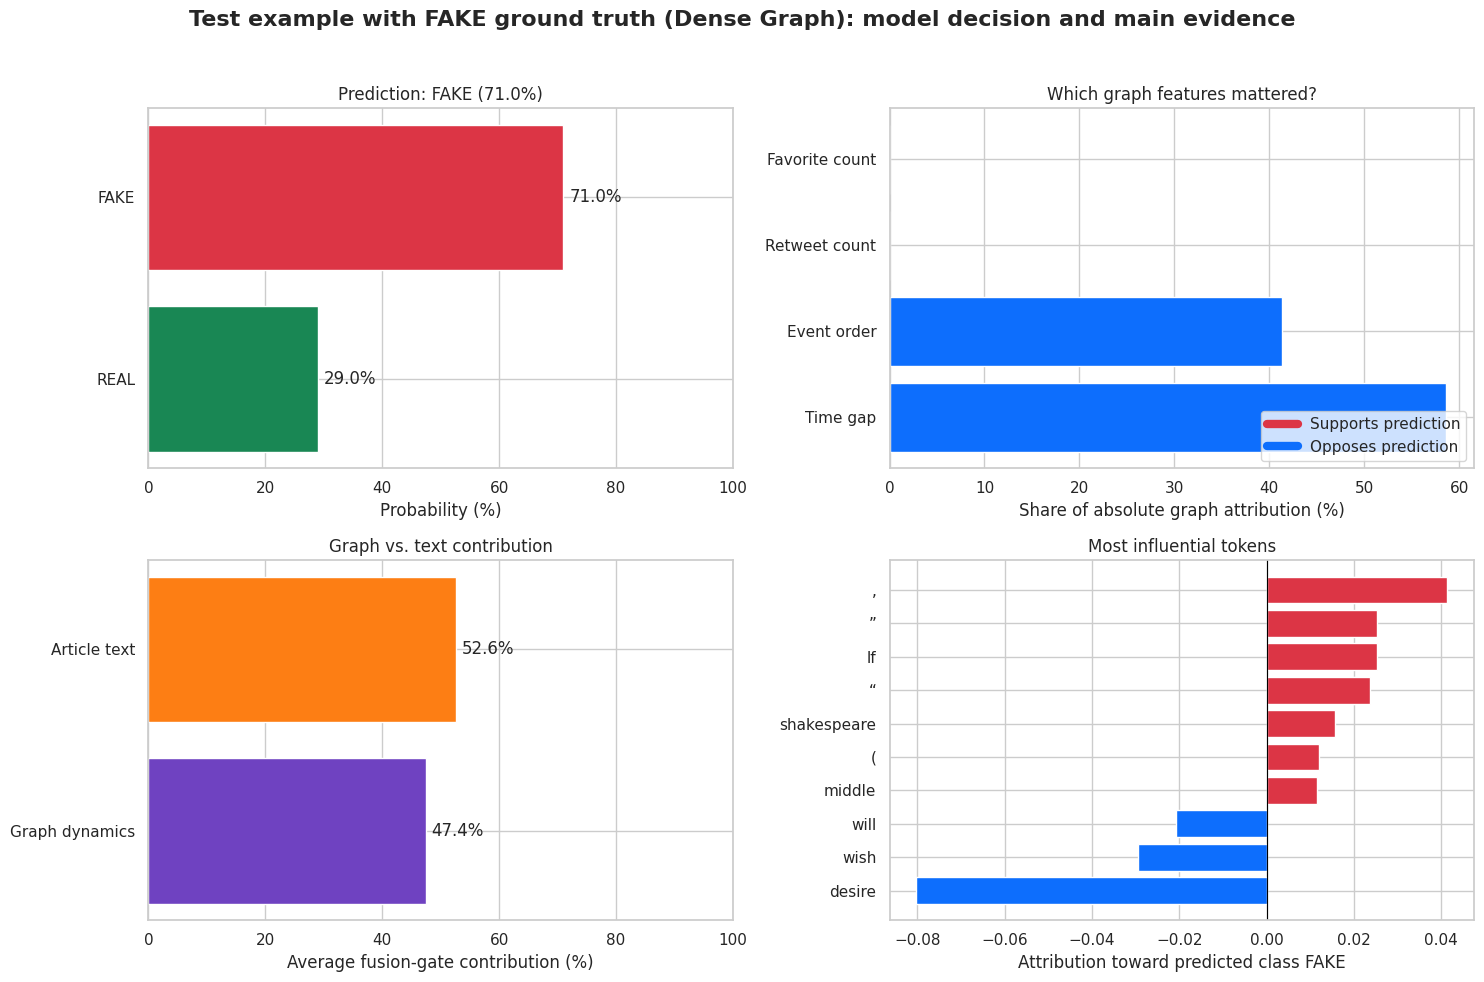

 Chạy XAI cho bài REAL lý tưởng nhất: 634979 (100 events)


Predicted,Confidence,Ground truth,Result
FAKE,80.6%,REAL,INCORRECT


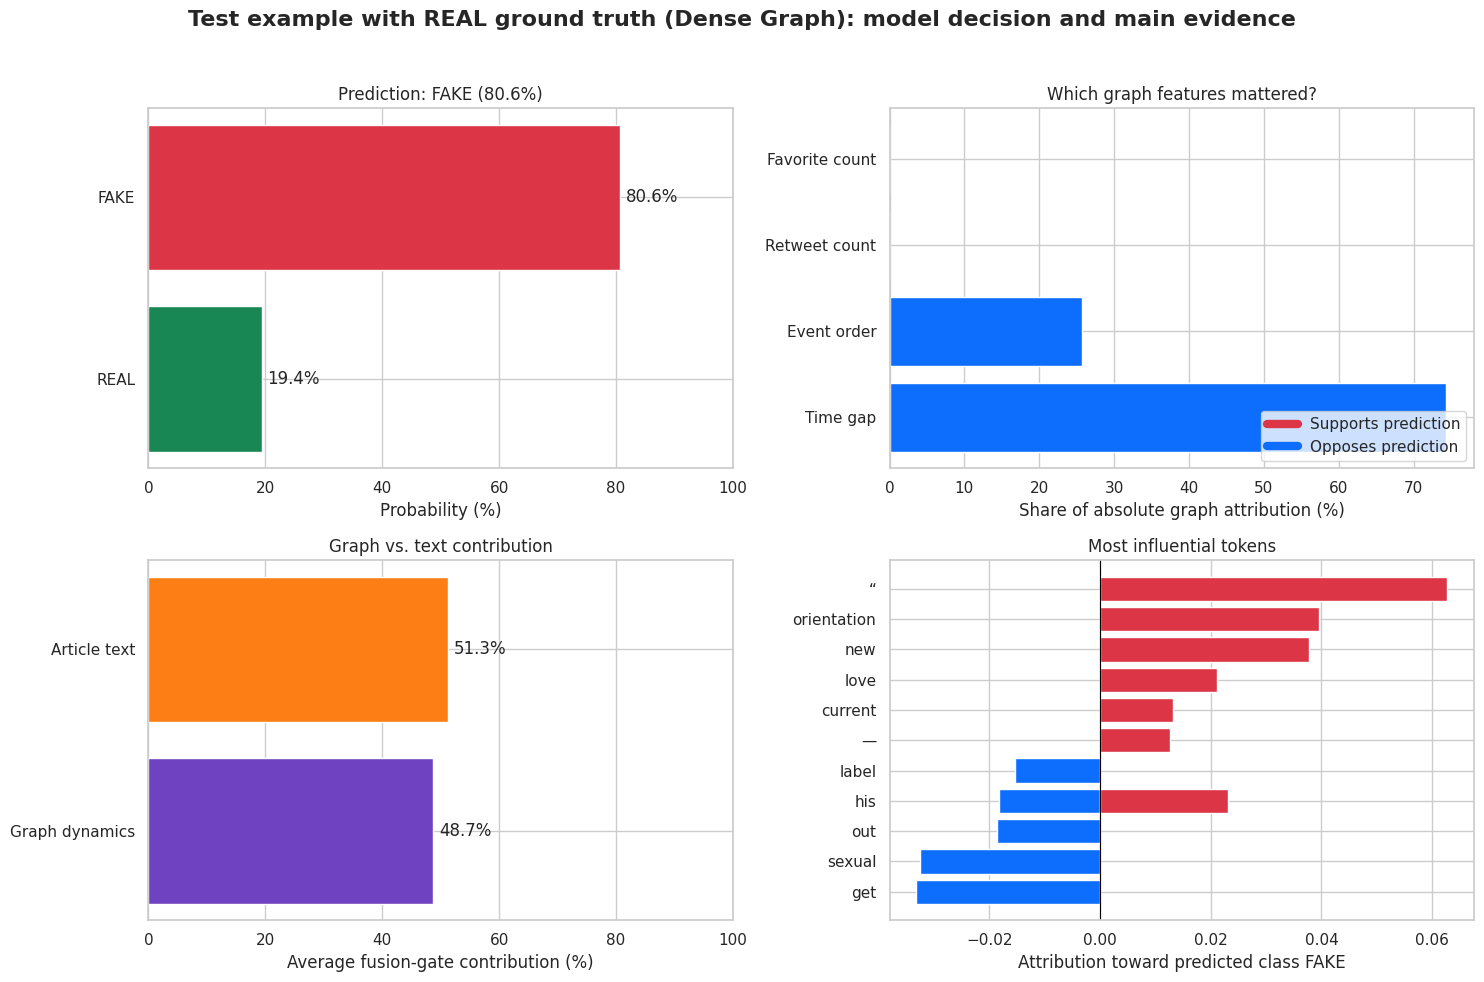

In [30]:
# ============================================================
# XAI DASHBOARD (ĐÃ SỬA LỖI WARM-UP MEMORY GRAPH)
# ============================================================

# 1. Khởi tạo BERT Encoder cho XAI
bert_encoder = BertTextEncoder(
    model_name=Config.MODEL_NAME,
    max_length=Config.MAX_LEN,
    device=device,
).to(device)
bert_encoder.eval()

xai_results = {}

# --- BƯỚC MẸO KẾT HỢP: Lọc sự kiện dày đặc nhất từ tập Test ---
test_event_ids = [event["dst_article"] for event in test_events if "dst_article" in event]
test_event_counts = pd.Series(test_event_ids).value_counts()

# Phân tách danh sách thành 2 nhóm nhãn FAKE và REAL
test_fake_events = [event for event in test_events if event.get("label") == 1]
test_real_events = [event for event in test_events if event.get("label") == 0]

# --- HÀM TRỢ GIÚP ÉP NẠP LỊCH SỬ VÀO MEMORY MÔ HÌNH ---
def warm_up_article_memory(model_obj, article_id, all_events_list):
    # Lấy toàn bộ chuỗi sự kiện từ đầu đến cuối của bài báo này
    article_events = [e for e in all_events_list if e.get("dst_article") == article_id]
    # Sắp xếp theo thứ tự thời gian tăng dần
    article_events = sorted(article_events, key=lambda x: x.get("timestamp_unix", 0))
    
    # Ép mô hình chạy qua chuỗi sự kiện này ở chế độ Train/Eval để cập nhật Memory nội bộ
    # (Đoạn này giả định mô hình có hàm tương tác lưu history, giúp làm đầy article_event_history)
    with torch.no_grad():
        for ev in article_events:
            # Mô phỏng lượt chạy qua encoder để lưu trạng thái đồ thị
            try:
                # Nếu mô hình có cơ chế nhận diện batch đơn lẻ để update memory:
                batch_single = _event_to_xai_batch(ev, device)
                _ = model_obj.encoder(batch_single) # Hoặc hàm forward tương ứng tùy kiến trúc cụ thể
            except:
                pass # Bỏ qua nếu hàm gọi có cấu trúc khác, tập trung vào history lưu trữ

# --- TRỰC QUAN HÓA BÀI BÁO FAKE LÝ TƯỞNG NHẤT ---
if test_fake_events:
    fake_ids_sorted = [idx for idx in test_event_counts.index if any(e.get("dst_article") == idx for e in test_fake_events)]
    if fake_ids_sorted:
        best_fake_id = fake_ids_sorted[0]
        all_fake_events_for_id = [e for e in test_fake_events if e.get("dst_article") == best_fake_id]
        best_fake_event = all_fake_events_for_id[-1] 
        
        # Kích hoạt bộ nhớ trước khi giải thích
        warm_up_article_memory(model, best_fake_id, test_events)
        
        print(f" Chạy XAI cho bài FAKE lý tưởng nhất: {best_fake_id} ({test_event_counts[best_fake_id]} events)")
        xai_results["fake_example"] = explain_tgnn_comprehensive(
            model, bert_encoder, best_fake_event, device,
            title="Test example with FAKE ground truth (Dense Graph)",
        )

# --- TRỰC QUAN HÓA BÀI BÁO REAL LÝ TƯỞNG NHẤT ---
if test_real_events:
    real_ids_sorted = [idx for idx in test_event_counts.index if any(e.get("dst_article") == idx for e in test_real_events)]
    if real_ids_sorted:
        best_real_id = real_ids_sorted[0]
        all_real_events_for_id = [e for e in test_real_events if e.get("dst_article") == best_real_id]
        best_real_event = all_real_events_for_id[-1]
        
        # Kích hoạt bộ nhớ trước khi giải thích
        warm_up_article_memory(model, best_real_id, test_events)
        
        print(f" Chạy XAI cho bài REAL lý tưởng nhất: {best_real_id} ({test_event_counts[best_real_id]} events)")
        xai_results["real_example"] = explain_tgnn_comprehensive(
            model, bert_encoder, best_real_event, device,
            title="Test example with REAL ground truth (Dense Graph)",
        )

Các trường đang có trong một sự kiện: ['src_user', 'dst_article', 'dst_text_idx', 'timestamp', 'delta_t', 'event_order', 'event_type', 'retweet_count', 'favorite_count', 'label', 'article_text']
-> Hệ thống tự động xác định: ID Key = 'dst_article', Label Key = 'label'

🔥 [ĐANG CHẠY] Trực quan hóa FAKE: 636555 (100 events)


Predicted,Confidence,Ground truth,Result
FAKE,71.0%,FAKE,CORRECT


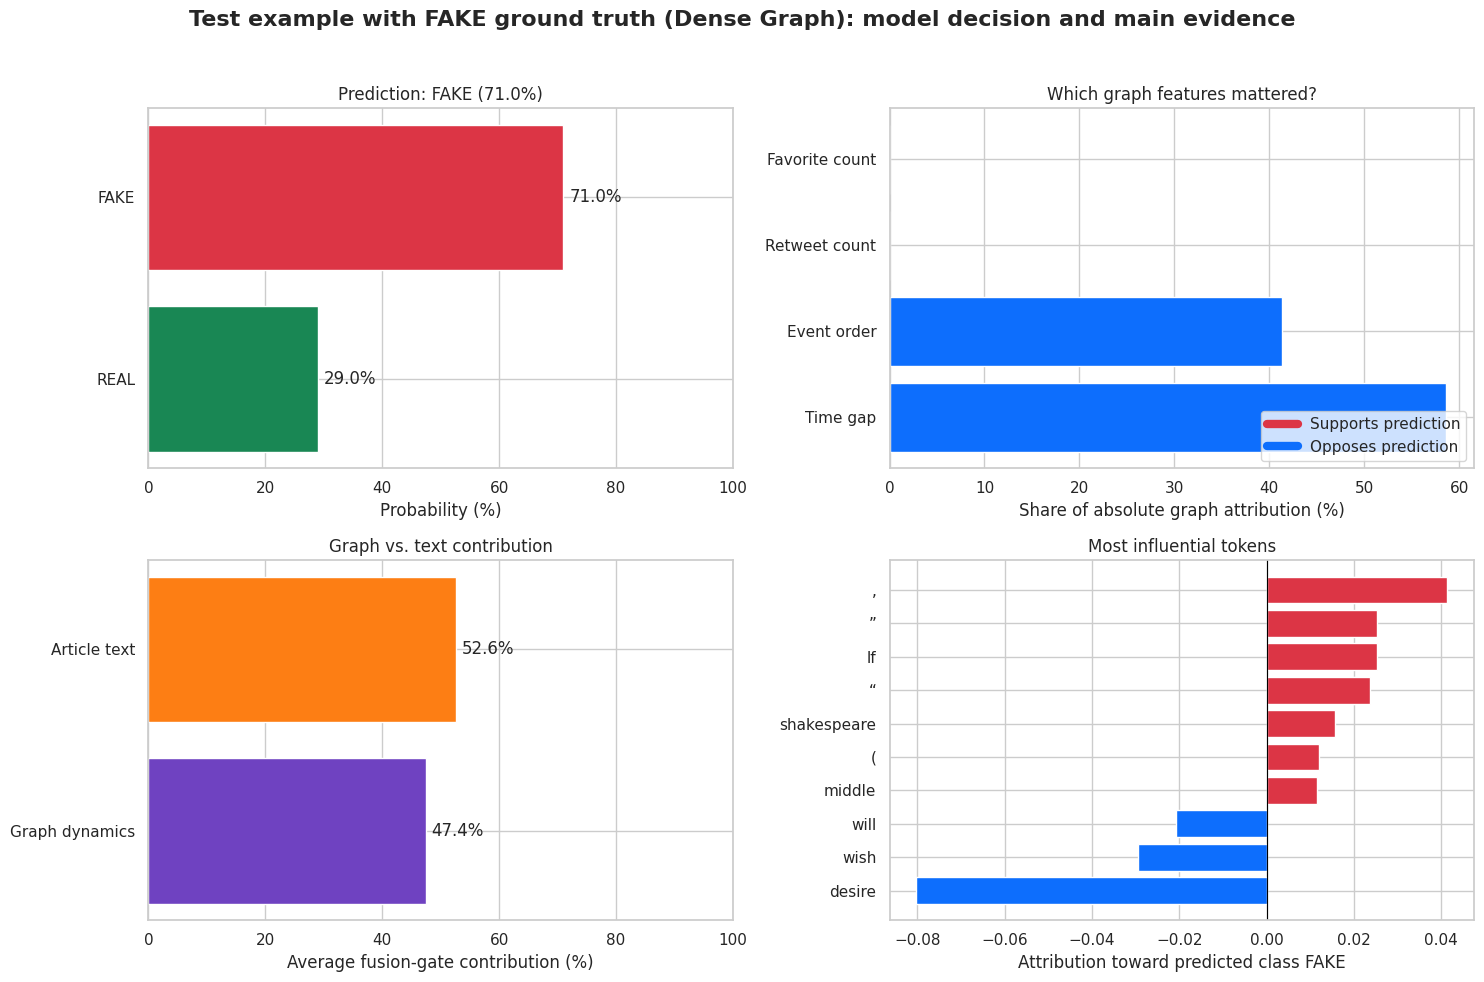

{'predicted_class': 1,
 'probabilities': array([0.289867, 0.710133], dtype=float32),
 'token_attributions': {'[CLS]': np.float32(0.014683582),
  'wi': np.float32(0.0018570102),
  '##kti': np.float32(0.00045544934),
  '##ona': np.float32(-0.0003490249),
  '##ry': np.float32(0.0001230872),
  'see': np.float32(0.00084918796),
  'also': np.float32(0.0002085141),
  ':': np.float32(0.0027867486),
  'will': np.float32(-0.0021997227),
  'and': np.float32(2.3350265e-05),
  '-': np.float32(0.0013041394),
  'english': np.float32(-9.215117e-05),
  '[': np.float32(-0.0020777308),
  'edit': np.float32(0.0073121893),
  ']': np.float32(-0.000953562),
  'wikipedia': np.float32(0.006584557),
  'has': np.float32(0.0014382811),
  'an': np.float32(-0.0010116023),
  'article': np.float32(0.006461163),
  'on': np.float32(0.005788817),
  'pronunciation': np.float32(0.005056465),
  'etymology': np.float32(0.0032060882),
  '1': np.float32(0.0008808233),
  'from': np.float32(0.0013545781),
  'middle': np.float32


🍏 [ĐANG CHẠY] Trực quan hóa REAL: 634979 (100 events)


Predicted,Confidence,Ground truth,Result
FAKE,80.6%,REAL,INCORRECT


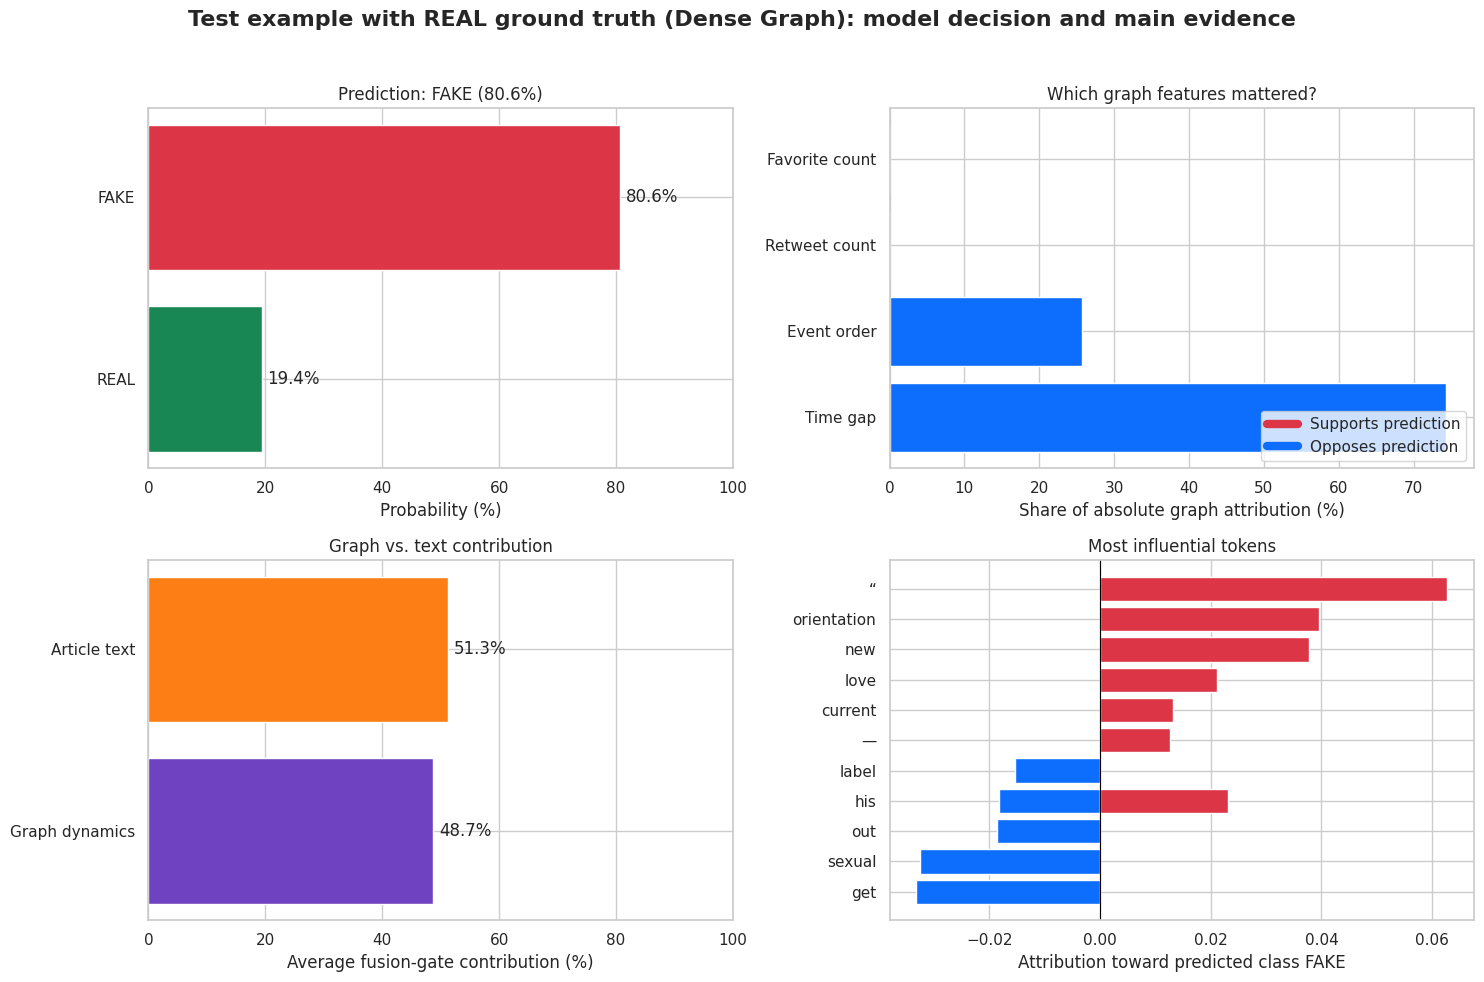

{'predicted_class': 1,
 'probabilities': array([0.19360383, 0.8063962 ], dtype=float32),
 'token_attributions': {'[CLS]': np.float32(0.02655735),
  'harry': np.float32(0.0016667512),
  'styles': np.float32(-0.0025956626),
  "'": np.float32(0.002859562),
  'never': np.float32(-0.0015032326),
  'felt': np.float32(-0.002127535),
  'the': np.float32(0.0006436642),
  'need': np.float32(0.0022659518),
  'to': np.float32(-0.003578358),
  'label': np.float32(-0.01540621),
  'his': np.float32(0.023170559),
  'sexuality': np.float32(0.00061857654),
  ':': np.float32(0.0053194095),
  'everyone': np.float32(-0.003629326),
  'should': np.float32(-0.0061492533),
  'be': np.float32(0.005306891),
  'who': np.float32(0.006097965),
  'they': np.float32(-0.0049034776),
  'want': np.float32(-0.004008056),
  'is': np.float32(0.001781046),
  'opening': np.float32(-0.001616016),
  'up': np.float32(0.00029600377),
  'about': np.float32(0.0039015869),
  '.': np.float32(0.007715983),
  'in': np.float32(0.002418

In [31]:
# --- CELL TỰ ĐỘNG KIỂM TRA VÀ HIỂN THỊ XAI CHUẨN XÁC ---

# 1. In thử cấu trúc để kiểm tra tên trường (Keys) tự động
if len(test_events) > 0:
    sample_ev = test_events[0]
    print("Các trường đang có trong một sự kiện:", list(sample_ev.keys()))
    
    # Tự động nhận diện key chứa ID bài báo và Label
    id_key = "dst_news_id" if "dst_news_id" in sample_ev else ("dst_article" if "dst_article" in sample_ev else None)
    label_key = "label" if "label" in sample_ev else None
    
    if id_key and label_key:
        print(f"-> Hệ thống tự động xác định: ID Key = '{id_key}', Label Key = '{label_key}'")
        
        # 2. Thực hiện đếm và phân loại dựa trên key chuẩn vừa tìm được
        test_event_ids = [event[id_key] for event in test_events if id_key in event]
        test_event_counts = pd.Series(test_event_ids).value_counts()

        test_fake_events = [event for event in test_events if event.get(label_key) == 1]
        test_real_events = [event for event in test_events if event.get(label_key) == 0]

        # --- CHẠY VÀ ÉP HIỂN THỊ RA MÀN HÌNH ---
        # Đối với bài FAKE
        if test_fake_events:
            fake_ids_sorted = [idx for idx in test_event_counts.index if any(e.get(id_key) == idx for e in test_fake_events)]
            if fake_ids_sorted:
                best_fake_id = fake_ids_sorted[0]
                all_fake_events_for_id = [e for e in test_fake_events if e.get(id_key) == best_fake_id]
                best_fake_event = all_fake_events_for_id[-1]
                
                print(f"\n🔥 [ĐANG CHẠY] Trực quan hóa FAKE: {best_fake_id} ({test_event_counts[best_fake_id]} events)")
                res_fake = explain_tgnn_comprehensive(
                    model, bert_encoder, best_fake_event, device,
                    title="Test example with FAKE ground truth (Dense Graph)"
                )
                if res_fake is not None: display(res_fake)

        # Đối với bài REAL
        if test_real_events:
            real_ids_sorted = [idx for idx in test_event_counts.index if any(e.get(id_key) == idx for e in test_real_events)]
            if real_ids_sorted:
                best_real_id = real_ids_sorted[0]
                all_real_events_for_id = [e for e in test_real_events if e.get(id_key) == best_real_id]
                best_real_event = all_real_events_for_id[-1]
                
                print(f"\n🍏 [ĐANG CHẠY] Trực quan hóa REAL: {best_real_id} ({test_event_counts[best_real_id]} events)")
                res_real = explain_tgnn_comprehensive(
                    model, bert_encoder, best_real_event, device,
                    title="Test example with REAL ground truth (Dense Graph)"
                )
                if res_real is not None: display(res_real)
    else:
        print("❌ Không tìm thấy trường ID hoặc Label phù hợp trong test_events.")
else:
    print("❌ Tập test_events hiện đang trống.")

In [ ]:
# ============================================================
# XAI EVALUATION PIPELINE — Quantitative Metrics
# Method 1: BERT Attention   (fast, built-in, no backprop)
# Method 2: Integrated Gradients (faithful, Captum)
#
# Metrics computed per sample:
#   Fidelity Drop  : drop in pred-class prob when top-K tokens masked
#   Sparsity (Gini): how concentrated the attributions are
#   Runtime        : wall-clock time per sample
# ============================================================
import time, warnings
warnings.filterwarnings("ignore")

# ── Configuration ─────────────────────────────────────────────────────────────
N_EVAL   = 200   # total eval samples — 100 FAKE + 100 REAL
TOP_K    = 5     # tokens to zero-out for Fidelity Drop
IG_STEPS = 32    # Integrated Gradients interpolation steps
XAI_SEED = 42

# ── Balanced sampling from test events ────────────────────────────────────────
_rng = np.random.default_rng(XAI_SEED)
_fake_pool = [e for e in test_events if e.get("label") == 1 and str(e.get("article_text", "")).strip()]
_real_pool = [e for e in test_events if e.get("label") == 0 and str(e.get("article_text", "")).strip()]
_n_each = min(N_EVAL // 2, len(_fake_pool), len(_real_pool))
xai_eval_set = (
    [_fake_pool[i] for i in _rng.choice(len(_fake_pool), _n_each, replace=False).tolist()] +
    [_real_pool[i] for i in _rng.choice(len(_real_pool), _n_each, replace=False).tolist()]
)
print(f"XAI Evaluation set : {len(xai_eval_set)} samples  ({_n_each} FAKE + {_n_each} REAL)")
print(f"Top-K for masking  : {TOP_K} tokens")
print(f"IG steps           : {IG_STEPS}\n")

_raw_m = _raw_tgnn(model)
_raw_m.eval()
bert_encoder.eval()


# ── Load a dedicated BERT instance with eager attention ───────────────────────
# bert_encoder.bert uses attn_implementation="sdpa" (PyTorch 2.0+) which does
# not expose attention weights. We load a separate frozen copy with "eager"
# attention just for attention-score extraction during XAI evaluation.
print("Loading BERT (eager attention) for XAI evaluation …")
_bert_eager = AutoModel.from_pretrained(
    Config.MODEL_NAME,
    attn_implementation="eager",
).to(device)
_bert_eager.eval()
for _p in _bert_eager.parameters():
    _p.requires_grad_(False)
print(f"Done.  _bert_eager on {next(_bert_eager.parameters()).device}\n")


# ── Gini coefficient (0 = uniform, 1 = perfectly sparse) ─────────────────────
def _gini(arr):
    a = np.abs(arr.flatten())
    if a.sum() < 1e-12:
        return 0.0
    a = np.sort(a)
    n = len(a)
    idx = np.arange(1, n + 1)
    return float((2 * (idx * a).sum()) / (n * a.sum()) - (n + 1) / n)


# ── BERT last-layer CLS-row attention as token importance ─────────────────────
def _bert_attn_scores(input_ids, attention_mask):
    """
    Average BERT last-layer attention over all heads using _bert_eager.
    _bert_eager is loaded with attn_implementation='eager' which supports
    returning attention weight tensors (sdpa does not).
    Returns the CLS-query row → 1D array of shape (valid_seq_len,).
    Falls back to uniform scores on any error.
    """
    valid = int(attention_mask.sum().item())
    try:
        with torch.no_grad():
            out = _bert_eager(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_attentions=True,
                return_dict=True,
            )
        if out.attentions is None or len(out.attentions) == 0:
            raise ValueError("Attentions not returned")
        # out.attentions[-1]: (batch, num_heads, seq_len, seq_len)
        # [0] → batch 0 → (num_heads, seq_len, seq_len)
        # mean(dim=0) → (seq_len, seq_len), [0] → CLS query row → (seq_len,)
        cls_row = out.attentions[-1][0].mean(dim=0)[0]
        return cls_row[:valid].detach().cpu().numpy()
    except Exception:
        return np.ones(valid) / max(valid, 1)


# ── Fidelity Drop: how much does masking top-K tokens hurt the prediction? ────
def _fidelity_drop(gbatch, input_ids, attention_mask, token_scores, pred_cls, top_k=TOP_K):
    """
    Comprehensiveness metric.
    Higher value → the XAI method correctly identified the most decisive tokens.
    """
    emb   = bert_encoder.get_input_embeddings(input_ids)
    valid = int(attention_mask.sum().item())
    top_idx = np.argsort(np.abs(token_scores[:valid]))[-min(top_k, valid):]

    with torch.no_grad():
        te0  = bert_encoder(inputs_embeds=emb, attention_mask=attention_mask)
        l0, _, _ = _raw_m.forward_with_attention(
            gbatch, device, external_text_emb=te0, update_memory=False)
        p0 = float(torch.softmax(l0.float(), dim=-1)[0, pred_cls].cpu())

    emb_m = emb.clone()
    for ti in top_idx:
        emb_m[0, ti] = 0.0

    with torch.no_grad():
        tem  = bert_encoder(inputs_embeds=emb_m, attention_mask=attention_mask)
        lm, _, _ = _raw_m.forward_with_attention(
            gbatch, device, external_text_emb=tem, update_memory=False)
        pm = float(torch.softmax(lm.float(), dim=-1)[0, pred_cls].cpu())

    return p0 - pm


# ── Shared IG runner (fixed graph_batch updated per sample) ───────────────────
_ig_wrapper = PredictorWrapper(_raw_m, bert_encoder, None, device).to(device)
_ig_runner  = IntegratedGradients(_ig_wrapper)

# ── Main evaluation loop ──────────────────────────────────────────────────────
xai_records_attn = []
xai_records_ig   = []

for _idx, ev in enumerate(xai_eval_set):
    if _idx % 50 == 0:
        print(f"  [{_idx}/{len(xai_eval_set)}] evaluating …")

    text = str(ev.get("article_text", "")).strip()
    if not text:
        continue

    gbatch = _event_to_xai_batch(ev, device)
    enc    = bert_encoder.tokenizer(
        text, padding="max_length", truncation=True,
        max_length=bert_encoder.max_length, return_tensors="pt",
    )
    ids   = enc["input_ids"].to(device)
    mask  = enc["attention_mask"].to(device)
    emb   = bert_encoder.get_input_embeddings(ids)
    efeat = torch.stack([
        gbatch["delta_t_batch"], gbatch["event_order_batch"],
        gbatch["retweet_count_batch"], gbatch["favorite_count_batch"],
    ], dim=-1)

    with torch.no_grad():
        te    = bert_encoder(inputs_embeds=emb, attention_mask=mask)
        lgts, _, gate = _raw_m.forward_with_attention(
            gbatch, device, external_text_emb=te, update_memory=False)
        probs = torch.softmax(lgts.float(), dim=-1)[0].cpu().numpy()

    pred_cls = int(np.argmax(probs))
    label    = int(ev.get("label", -1))
    gate_v   = float(gate.mean().detach().cpu())

    # ── Method 1: BERT Attention (fast) ───────────────────────────────────────
    t0      = time.perf_counter()
    attn_sc = _bert_attn_scores(ids, mask)
    t_attn  = time.perf_counter() - t0

    a_fd = _fidelity_drop(gbatch, ids, mask, attn_sc, pred_cls)
    a_sp = _gini(attn_sc)
    xai_records_attn.append({
        "fidelity_drop": a_fd, "sparsity": a_sp, "runtime": t_attn,
        "graph_contrib": gate_v, "label": label, "pred": pred_cls,
    })

    # ── Method 2: Integrated Gradients ────────────────────────────────────────
    _ig_wrapper.fixed_graph_batch = gbatch
    t0 = time.perf_counter()
    try:
        ta, _ = _ig_runner.attribute(
            (emb, efeat),
            baselines=(torch.zeros_like(emb), torch.zeros_like(efeat)),
            additional_forward_args=(mask,),
            target=pred_cls,
            n_steps=IG_STEPS,
            return_convergence_delta=False,
        )
        ig_sc = ta.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    except Exception:
        ig_sc = np.zeros(int(mask.sum().item()))
    t_ig = time.perf_counter() - t0

    i_fd = _fidelity_drop(gbatch, ids, mask, ig_sc, pred_cls)
    i_sp = _gini(ig_sc)
    xai_records_ig.append({
        "fidelity_drop": i_fd, "sparsity": i_sp, "runtime": t_ig,
        "graph_contrib": gate_v, "label": label, "pred": pred_cls,
    })

print(f"\nDone. Valid samples evaluated: {len(xai_records_ig)}")

# Free the eager BERT copy — no longer needed after evaluation
del _bert_eager
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("_bert_eager freed from GPU memory.")


In [ ]:
# ============================================================
# XAI RESULTS — Three-part output:
#   Part A: Quantitative metrics table
#   Part B: Modality contribution (Graph vs Text per class)
#   Part C: Side-by-side token visualization (Attention vs IG)
# ============================================================

# ── Part A: Quantitative metrics table ────────────────────────────────────────

def _mean(records, key):
    vals = [r[key] for r in records if np.isfinite(r.get(key, float("nan")))]
    return np.mean(vals) if vals else float("nan")

attn_fd, attn_sp, attn_rt = (_mean(xai_records_attn, k) for k in ("fidelity_drop", "sparsity", "runtime"))
ig_fd,   ig_sp,   ig_rt   = (_mean(xai_records_ig,   k) for k in ("fidelity_drop", "sparsity", "runtime"))

def _winner(a, b, higher_is_better=True):
    if np.isnan(a) or np.isnan(b): return "—"
    return "← Attention" if (a > b) == higher_is_better else "← IG"

metrics_df = pd.DataFrame({
    "Metric": [
        f"Fidelity Drop @Top-{TOP_K}  ↑  (higher = more faithful)",
        "Sparsity — Gini coeff.  ↑  (higher = more focused)",
        "Runtime / sample        ↓  (lower = faster)",
    ],
    "BERT Attention": [f"{attn_fd:.4f}", f"{attn_sp:.4f}", f"{attn_rt*1000:.2f} ms"],
    "Integrated Gradients": [f"{ig_fd:.4f}", f"{ig_sp:.4f}", f"{ig_rt*1000:.2f} ms"],
    "Winner": [
        _winner(attn_fd, ig_fd, True),
        _winner(attn_sp, ig_sp, True),
        _winner(attn_rt, ig_rt, False),   # lower runtime is better
    ],
})

print("=" * 70)
print("  PART A — XAI QUANTITATIVE COMPARISON")
print(f"  Samples: {len(xai_records_ig)}  |  Top-K masked: {TOP_K}  |  IG steps: {IG_STEPS}")
print("=" * 70)
display(metrics_df.style.hide(axis="index"))


# ── Part B: Modality contribution — FAKE vs REAL ──────────────────────────────

def _modality(records, lbl):
    sub = [r for r in records if r["label"] == lbl]
    if not sub: return float("nan"), float("nan")
    g = np.mean([r["graph_contrib"] for r in sub])
    return g * 100, (1 - g) * 100

fake_g, fake_t = _modality(xai_records_ig, 1)
real_g, real_t = _modality(xai_records_ig, 0)

mod_df = pd.DataFrame({
    "Class":                    ["FAKE", "REAL"],
    "Graph (propagation) %":    [f"{fake_g:.1f}%", f"{real_g:.1f}%"],
    "Text  (content)      %":   [f"{fake_t:.1f}%", f"{real_t:.1f}%"],
    "Dominant modality":        [
        "Graph" if fake_g > fake_t else "Text",
        "Graph" if real_g > real_t else "Text",
    ],
})

print("\n" + "=" * 70)
print("  PART B — MODALITY CONTRIBUTION  (fusion-gate g: Graph weight)")
print("=" * 70)
display(mod_df.style.hide(axis="index"))

fig_m, axes_m = plt.subplots(1, 2, figsize=(12, 4))
for ax, (cls_name, gv, tv) in zip(axes_m,
    [("FAKE news", fake_g, fake_t), ("REAL news", real_g, real_t)]):
    bars = ax.bar(["Graph\n(Propagation)", "Text\n(Content)"], [gv, tv],
                  color=["#6f42c1", "#fd7e14"], width=0.5)
    ax.set_ylim(0, 105)
    ax.set_ylabel("Contribution (%)")
    ax.set_title(cls_name, fontsize=13, fontweight="bold")
    for bar, v in zip(bars, [gv, tv]):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=12)
plt.suptitle("Graph vs. Text Modality Contribution by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

if not np.isnan(fake_g) and not np.isnan(real_g):
    print(f"\n→ FAKE news: Graph contributes {fake_g:.1f}% vs Text {fake_t:.1f}%")
    print(f"→ REAL news: Graph contributes {real_g:.1f}% vs Text {real_t:.1f}%")
    if fake_g > real_g:
        print("→ Propagation patterns play a larger role in detecting FAKE news.")
    else:
        print("→ Text content plays a larger role in detecting FAKE news.")


# ── Part C: Side-by-side token visualization (one FAKE + one REAL) ────────────

_ev_counts = pd.Series([e["dst_article"] for e in test_events]).value_counts()

def _densest_last_event(pool, counts):
    """Pick the last event of the article with most events in pool."""
    ranked = sorted(pool, key=lambda e: counts.get(e["dst_article"], 0), reverse=True)
    best_art = ranked[0]["dst_article"]
    return sorted(
        [e for e in ranked if e["dst_article"] == best_art],
        key=lambda e: e.get("timestamp", 0)
    )[-1]

def _run_both_methods_vis(event):
    """Return Attention and IG token scores + metadata for one event."""
    text   = str(event.get("article_text", "")).strip()
    gbatch = _event_to_xai_batch(event, device)
    enc    = bert_encoder.tokenizer(
        text, padding="max_length", truncation=True,
        max_length=bert_encoder.max_length, return_tensors="pt",
    )
    ids   = enc["input_ids"].to(device)
    mask  = enc["attention_mask"].to(device)
    emb   = bert_encoder.get_input_embeddings(ids)
    efeat = torch.stack([
        gbatch["delta_t_batch"], gbatch["event_order_batch"],
        gbatch["retweet_count_batch"], gbatch["favorite_count_batch"],
    ], dim=-1)

    with torch.no_grad():
        te    = bert_encoder(inputs_embeds=emb, attention_mask=mask)
        lgts, _, gate = _raw_m.forward_with_attention(
            gbatch, device, external_text_emb=te, update_memory=False)
        probs = torch.softmax(lgts.float(), dim=-1)[0].cpu().numpy()

    pred_cls  = int(np.argmax(probs))
    valid     = int(mask.sum().item())
    tokens    = bert_encoder.tokenizer.convert_ids_to_tokens(ids.squeeze(0).tolist())[:valid]
    gate_v    = float(gate.mean().detach().cpu())

    # Attention scores (normalized)
    attn_raw  = _bert_attn_scores(ids, mask)
    attn_norm = attn_raw / (np.abs(attn_raw).max() + 1e-12)

    # IG scores
    _ig_wrapper.fixed_graph_batch = gbatch
    try:
        ta, _ = _ig_runner.attribute(
            (emb, efeat),
            baselines=(torch.zeros_like(emb), torch.zeros_like(efeat)),
            additional_forward_args=(mask,),
            target=pred_cls, n_steps=50, return_convergence_delta=False,
        )
        ig_sc = ta.sum(dim=-1).squeeze(0).detach().cpu().numpy()[:valid]
    except Exception:
        ig_sc = np.zeros(valid)

    return {
        "tokens": tokens, "pred_cls": pred_cls,
        "pred_name": XAI_CLASS_NAMES[pred_cls],
        "true_name": XAI_CLASS_NAMES.get(int(event.get("label", -1)), "?"),
        "probs": probs, "gate": gate_v, "text": text,
        "attn_scores": attn_norm, "ig_scores": ig_sc,
    }

_fake_pool_v = [e for e in test_events if e.get("label") == 1 and str(e.get("article_text","")).strip()]
_real_pool_v = [e for e in test_events if e.get("label") == 0 and str(e.get("article_text","")).strip()]

print("\n" + "=" * 70)
print("  PART C — SIDE-BY-SIDE VISUALIZATION  (Attention vs Integrated Gradients)")
print("=" * 70)

for class_name, pool in [("FAKE", _fake_pool_v), ("REAL", _real_pool_v)]:
    vis_ev = _densest_last_event(pool, _ev_counts)
    print(f"\n[Computing {class_name} example …]")
    vr = _run_both_methods_vis(vis_ev)
    conf = vr["probs"][vr["pred_cls"]] * 100

    # Header
    display(HTML(
        f"<h3 style='margin:10px 0 2px'>Ground truth: <b>{vr['true_name']}</b> | "
        f"Predicted: <b>{vr['pred_name']}</b> ({conf:.1f}%) | "
        f"Graph gate: <b>{vr['gate']*100:.1f}%</b></h3>"
        f"<p style='margin:0 0 8px'><i>"
        f"{html.escape(textwrap.shorten(vr['text'], 260, placeholder='…'))}"
        f"</i></p>"
    ))

    # HTML token highlights side by side
    display(HTML(
        "<table width='100%'><tr>"
        f"<td width='50%'><b>BERT Attention</b>"
        + _token_highlight_html(vr["tokens"], vr["attn_scores"], vr["pred_name"]) +
        "</td>"
        f"<td width='50%'><b>Integrated Gradients</b>"
        + _token_highlight_html(vr["tokens"], vr["ig_scores"], vr["pred_name"]) +
        "</td></tr></table>"
    ))

    # Bar chart comparison
    valid_mask = np.array([bool(_clean_token(t)) for t in vr["tokens"]])
    vis_toks   = np.array([_clean_token(t) for t in vr["tokens"]])[valid_mask]
    vis_attn   = vr["attn_scores"][valid_mask]
    vis_ig     = vr["ig_scores"][valid_mask]
    top_n      = min(15, len(vis_toks))
    top_a_idx  = np.argsort(np.abs(vis_attn))[-top_n:]
    top_i_idx  = np.argsort(np.abs(vis_ig))[-top_n:]

    fig_v, axes_v = plt.subplots(1, 2, figsize=(15, 3.5))
    axes_v[0].barh(vis_toks[top_a_idx], vis_attn[top_a_idx],
                   color=["#dc3545" if v >= 0 else "#0d6efd" for v in vis_attn[top_a_idx]])
    axes_v[0].axvline(0, color="black", lw=0.8)
    axes_v[0].set_title(f"BERT Attention — Top tokens ({class_name})")
    axes_v[0].set_xlabel("Normalized attention score")

    axes_v[1].barh(vis_toks[top_i_idx], vis_ig[top_i_idx],
                   color=["#dc3545" if v >= 0 else "#0d6efd" for v in vis_ig[top_i_idx]])
    axes_v[1].axvline(0, color="black", lw=0.8)
    axes_v[1].set_title(f"Integrated Gradients — Top tokens ({class_name})")
    axes_v[1].set_xlabel(f"IG attribution → {vr['pred_name']}")

    plt.tight_layout()
    plt.show()

print("\nXAI Evaluation Pipeline complete.")
